In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import html
from pathlib import Path

from collections import Counter

import nltk
import pandas as pd
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

In [2]:
def _ensure_nltk(pkg: str) -> None:
    try:
        if pkg == "stopwords":
            nltk.data.find("corpora/stopwords")
        elif pkg == "wordnet":
            nltk.data.find("corpora/wordnet")
        elif pkg in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{pkg}")
        else:
            nltk.data.find(f"taggers/{pkg}")
    except LookupError:
        nltk.download(pkg)


for _p in ("punkt_tab", "punkt", "stopwords", "wordnet", "averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
    _ensure_nltk(_p)

try:
    word_tokenize("ping")
except LookupError:
    nltk.download("punkt")
    nltk.download("punkt_tab")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lucian\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Phần 0: Đọc data - kiểm tra cơ bản

In [3]:
DATA_PATH = "data/Tweets.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 0.1: Thông tin cơ bản về Dataset

In [4]:
# Kiểm tra thông tin DataFrame
print("=" * 60)
print("THÔNG TIN DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("MÔ TẢ THỐNG KÊ")
print("=" * 60)
display(df.describe())

THÔNG TIN DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-nu

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


## 0.2: Kiểm tra Missing Values

In [5]:
# Kiểm tra missing values và tỷ lệ missing values theo cột
missing_df = pd.DataFrame({
    'Cột': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

print(f"\n✓ Tổng số dòng có ít nhất 1 giá trị missing: {df.isnull().any(axis=1).sum():,}")
print(f"✓ Tỷ lệ: {(df.isnull().any(axis=1).sum() / len(df) * 100):.2f}%")

MISSING VALUES ANALYSIS


,Cột,Missing Count,Missing %
negativereason_gold,negativereason_gold,14608,99.78
airline_sentiment_gold,airline_sentiment_gold,14600,99.73
tweet_coord,tweet_coord,13621,93.04
negativereason,negativereason,5462,37.31
user_timezone,user_timezone,4820,32.92
tweet_location,tweet_location,4733,32.33
negativereason_confidence,negativereason_confidence,4118,28.13



✓ Tổng số dòng có ít nhất 1 giá trị missing: 14,638
✓ Tỷ lệ: 99.99%


## 0.3:. Kiểm tra Duplicates

In [6]:
# Kiểm tra duplicates
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)
print(f"✓ Tổng số dòng: {len(df):,}")
print(f"✓ Số dòng duplicate (toàn bộ): {df.duplicated().sum():,}")
print(f"✓ Số dòng duplicate (chỉ text): {df.duplicated(subset=['text']).sum():,}")
print(f"✓ Số dòng unique (text): {df['text'].nunique():,}")

if df.duplicated(subset=['text']).sum() > 0:
    print(f"\n⚠️ Có {df.duplicated(subset=['text']).sum():,} tweets trùng lặp nội dung")
    print("   → Có thể do retweets hoặc copy-paste. Xem xét xử lý nếu cần.")
else:
    print("\n✓ Không có tweets trùng lặp!")

DUPLICATE ANALYSIS
✓ Tổng số dòng: 14,640
✓ Số dòng duplicate (toàn bộ): 36
✓ Số dòng duplicate (chỉ text): 213
✓ Số dòng unique (text): 14,427

⚠️ Có 213 tweets trùng lặp nội dung
   → Có thể do retweets hoặc copy-paste. Xem xét xử lý nếu cần.


# Phần 1. Tiền xử lý NLP cho Tweet (Airline Sentiment)

Dataset: [twitter-airline-sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) - phân tích cảm xúc tweet về các hãng hàng không Mỹ (2015).

**Mục tiêu:** Làm sạch và chuẩn hóa text để tạo features tốt cho machine learning models.

**Các bước chính:**
- **Phần 1.1:** Feature Engineering - Chọn cột `text` làm cột input
- **Phần 1.2:** Text Cleaning - Loại bỏ noise (mentions, hashtags, URLs, emojis)
- **Phần 1.3:** Text Normalization - Chuẩn hóa văn bản
- **Phần 1.4:** Linguistic Processing - Stop words removal & Lemmatization

**Pipeline:** Raw Text → Clean Noise → Normalize → Linguistic Process → Final Text

**12 bước xử lý:**

| Bước | Function | Mô tả | Ví dụ |
|------|----------|-------|-------|
| 1 | Feature Engineering | Chọn cột `text` | |
| 2 | `remove_username()` | Loại @mentions | "@United help" → "help" |
| 3 | `remove_hashtag()` | Loại #hashtags | "#fail service" → "service" |
| 4 | `remove_url()` | Loại URLs | "Check http://..." → "Check" |
| 5 | `remove_emoji()` | Loại emojis | "😡 angry" → "angry" |
| 6 | `decontraction()` | Mở rộng contractions | "can't" → "can not" |
| 7 | `seperate_alphanumeric()` | Tách số và chữ | "flight123" → "flight 123" |
| 8 | `unique_char()` | Giảm ký tự lặp | "sooooo" → "soo" |
| 9 | `char()` | Chỉ giữ chữ cái | "Service!!!" → "Service" |
| 10 | `lower()` | Lowercase | "BAD" → "bad" |
| 11 | `remove_stopwords()` | Loại stopwords | "the service is bad" → "service bad" |
| 12 | `lemmatize_text()` | Lemmatization với POS tagging | "running" → "run" |

In [7]:
# Tạo cột 'final_text' để lưu trữ văn bản đã được làm sạch
df['final_text'] = df['text']

## Phần 1.1: Text cleaning

In [8]:
# Remove stop words
def remove_stopwords(text):
    text = ' '.join([word for word in text.split() if word not in (stopwords.words('english'))])
    return text

# Remove url  
def remove_url(text):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'',text)

# Remove punct
def remove_punct(text):
    table = str.maketrans('', '', string.punctuation)
    return text.translate(table)

# Remove html 
def remove_html(text):
    html=re.compile(r'<.*?>')
    return html.sub(r'',text)

# Remove @username
def remove_username(text):
    return re.sub('@[^\s]+','',text)

# Remove #hashtag
def remove_hashtag(text):
    return re.sub(r'#\w+','',text)

# Remove emojis
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

## Phần 1.2: Text Normalization

In [9]:
# Decontraction text
def decontraction(text):
    text = re.sub(r"won\'t", " will not", text)
    text = re.sub(r"won\'t've", " will not have", text)
    text = re.sub(r"can\'t", " can not", text)
    text = re.sub(r"don\'t", " do not", text)
    
    text = re.sub(r"can\'t've", " can not have", text)
    text = re.sub(r"ma\'am", " madam", text)
    text = re.sub(r"let\'s", " let us", text)
    text = re.sub(r"ain\'t", " am not", text)
    text = re.sub(r"shan\'t", " shall not", text)
    text = re.sub(r"sha\n't", " shall not", text)
    text = re.sub(r"o\'clock", " of the clock", text)
    text = re.sub(r"y\'all", " you all", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"n\'t've", " not have", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'d've", " would have", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'ll've", " will have", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    text = re.sub(r"\'re", " are", text)
    return text  

# Seperate alphanumeric
def seperate_alphanumeric(text):
    words = text
    words = re.findall(r"[^\W\d_]+|\d+", words)
    return " ".join(words)

# Remove continuous repeated characters
def cont_rep_char(text):
    tchr = text.group(0) 
    
    if len(tchr) > 1:
        return tchr[0:2] 

# Remove non-alphabetic characters
def unique_char(rep, text):
    substitute = re.sub(r'(\w)\1+', rep, text)
    return substitute

# Remove non-alphabetic characters
def char(text):
    substitute = re.sub(r'[^a-zA-Z]',' ',text)
    return substitute


## Phần 1.4: Linguistic 

In [10]:
# Lemmatization with POS tagging
def get_wordnet_pos(tag):
    """Convert POS tag to wordnet tag"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Lemmatization with POS tagging
def lemmatize_text(text):
    """Lemmatize text with POS tagging"""
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]
    return ' '.join(lemmatized)

In [11]:
# Áp dụng các bước làm sạch văn bản
df['final_text'] = df['final_text'].apply(lambda x : remove_username(x))
df['final_text'] = df['final_text'].apply(lambda x : remove_url(x))
df['final_text'] = df['final_text'].apply(lambda x : remove_emoji(x))
df['final_text'] = df['final_text'].apply(lambda x : decontraction(x))
df['final_text'] = df['final_text'].apply(lambda x : seperate_alphanumeric(x))
df['final_text'] = df['final_text'].apply(lambda x : unique_char(cont_rep_char,x))
df['final_text'] = df['final_text'].apply(lambda x : char(x))
df['final_text'] = df['final_text'].apply(lambda x : x.lower())
df['final_text'] = df['final_text'].apply(lambda x : remove_stopwords(x))
df['final_text'] = df['final_text'].apply(lambda x : lemmatize_text(x))

In [12]:
# Kiểm tra kết quả preprocessing
print("Số lượng tweets:", len(df))
print("\n" + "="*80)
print("SAMPLE: So sánh BEFORE và AFTER preprocessing")
print("="*80)

# Lấy 3 samples
samples = df.sample(3, random_state=42)

for idx, (i, row) in enumerate(samples.iterrows(), 1):
    print(f"\n{'─'*80}")
    print(f"EXAMPLE {idx}:")
    print(f"{'─'*80}")
    
    # Original text
    original = row['text']
    print(f"📝 ORIGINAL TEXT:")
    print(f"   {original}")
    
    # Negative reason (if exists)
    # if pd.notna(row['negativereason']):
    #     print(f"\n🏷️  NEGATIVE REASON: {row['negativereason']}")
    
    # Processed text
    processed = row['final_text']
    print(f"\n✨ PROCESSED TEXT:")
    print(f"   {processed}")
    
    # Sentiment label
    print(f"\n🎯 SENTIMENT: {row['airline_sentiment'].upper()}")

print("\n" + "="*80)


Số lượng tweets: 14640

SAMPLE: So sánh BEFORE và AFTER preprocessing

────────────────────────────────────────────────────────────────────────────────
EXAMPLE 1:
────────────────────────────────────────────────────────────────────────────────
📝 ORIGINAL TEXT:
   @SouthwestAir you're my early frontrunner for best airline! #oscars2016

✨ PROCESSED TEXT:
   early frontrunner best airline oscar

🎯 SENTIMENT: POSITIVE

────────────────────────────────────────────────────────────────────────────────
EXAMPLE 2:
────────────────────────────────────────────────────────────────────────────────
📝 ORIGINAL TEXT:
   @USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?

✨ PROCESSED TEXT:
   flt ewr cancel flightled yet flts nyc usairways still fly

🎯 SENTIMENT: NEGATIVE

────────────────────────────────────────────────────────────────────────────────
EXAMPLE 3:
───────────────────────────────────────────────────────────────────────────────

# Phần 2. Khai phá dữ liệu (EDA) và Vector hóa

Phần này thực hiện phân tích dữ liệu khám phá (EDA) để hiểu rõ dataset và chuẩn bị dữ liệu cho modeling:

- **Phần 2.1:** Phân tích phân bố nhãn `airline_sentiment`
- **Phần 2.2:** Phân tích phân bố Airlines
- **Phần 2.3:** Phân tích Sentiment theo từng Airline
- **Phần 2.4:** Phân tích lý do phàn nàn (negative reasons) theo từng hãng hàng không
- **Phần 2.5:** Text Length Analysis
- **Phần 2.6:** Vector hóa text với TF-IDF

## Phần 2.1: Phân tích phân bố nhãn Sentiment

Phân tích phân bố của 3 nhãn sentiment (negative, neutral, positive) để hiểu mức độ cân bằng/mất cân bằng của dataset.

BẢNG PHÂN BỐ SENTIMENT


,sentiment,count,ratio
0,negative,9178,0.626913
1,neutral,3099,0.211680
2,positive,2363,0.161407


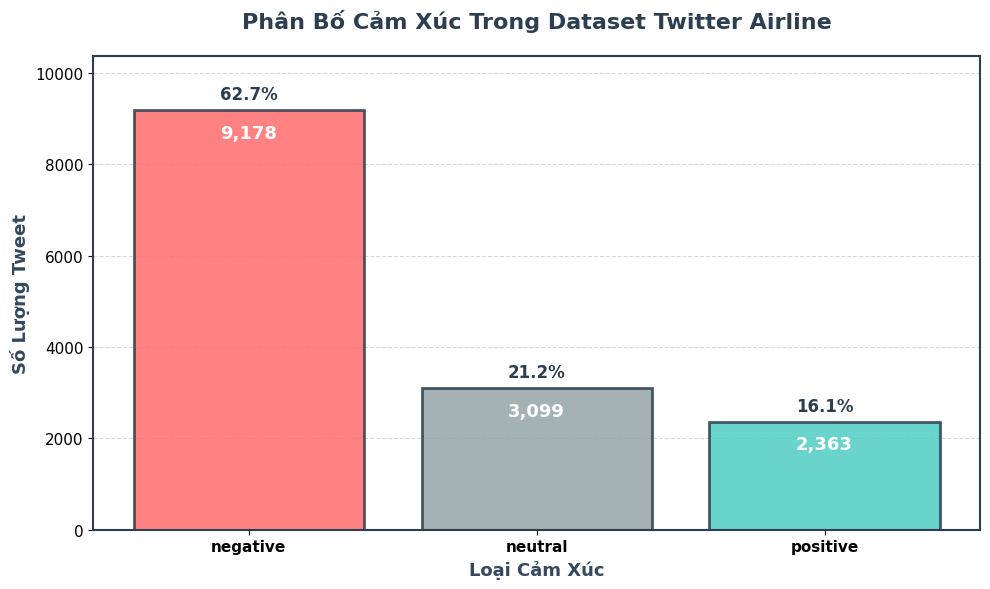

In [13]:
# ============================================================================
# PHÂN BỐ NHÃN SENTIMENT
# ============================================================================

sentiment_order = ["negative", "neutral", "positive"]

# Đếm số lượng mỗi nhãn và tính tỷ lệ phần trăm
sentiment_counts = (
    df["airline_sentiment"]
    .value_counts()
    .reindex(sentiment_order)
    .rename_axis("sentiment")
    .reset_index(name="count")
)
sentiment_counts["ratio"] = sentiment_counts["count"] / sentiment_counts["count"].sum()

# Hiển thị bảng phân bố sentiment
print("=" * 70)
print("BẢNG PHÂN BỐ SENTIMENT")
print("=" * 70)
display(sentiment_counts)

# ============================================================================
# VẼ BIỂU ĐỒ CỘT - PHÂN BỐ SENTIMENT
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Định nghĩa màu sắc đẹp mắt hơn
colors = ["#FF6B6B", "#95A5A6", "#4ECDC4"]  # Đỏ nhẹ, Xám, Xanh ngọc

# Vẽ biểu đồ cột
bars = ax.bar(
    sentiment_counts["sentiment"],
    sentiment_counts["count"],
    color=colors,
    edgecolor='#2C3E50',
    linewidth=2,
    alpha=0.85
)

# Tiêu đề và nhãn trục với font lớn và đẹp hơn
ax.set_title(
    "Phân Bố Cảm Xúc Trong Dataset Twitter Airline", 
    fontsize=16, 
    fontweight='bold',
    pad=20,
    color='#2C3E50'
)
ax.set_xlabel("Loại Cảm Xúc", fontsize=13, fontweight='bold', color='#34495E')
ax.set_ylabel("Số Lượng Tweet", fontsize=13, fontweight='bold', color='#34495E')

# Thêm grid để dễ đọc
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)

# Thêm nhãn số lượng và phần trăm trên mỗi cột
for bar, count, ratio in zip(bars, sentiment_counts["count"], sentiment_counts["ratio"]):
    height = bar.get_height()
    
    # Số lượng tweet
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        height - 300,
        f'{count:,}',
        ha='center',
        va='top',
        fontsize=13,
        fontweight='bold',
        color='white'
    )
    
    # Phần trăm
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 150,
        f'{ratio:.1%}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#2C3E50'
    )

# Điều chỉnh giới hạn trục y
ax.set_ylim(0, sentiment_counts["count"].max() * 1.13)

# Làm đẹp trục x
ax.tick_params(axis='both', labelsize=11)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

# Thêm khung viền cho plot
for spine in ax.spines.values():
    spine.set_edgecolor('#2C3E50')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


### 📊 Nhận xét về phân bố Sentiment:

Từ biểu đồ và bảng trên, ta quan sát:

- **Class Imbalance nghiêm trọng:** Dataset có mất cân bằng lớp rõ rệt
  - **Negative:** Chiếm đa số (~63%)
  - **Neutral:** Chiếm ~21% 
  - **Positive:** Thiểu số (~16%)

- **Hậu quả:**
  - Models có thể bias về class majority (negative)
  - F1-Score của classes thiểu số sẽ thấp
  - Cần techniques xử lý imbalance (SMOTE, class weights, etc.)

- **Ý nghĩa:**
  - Khách hàng có xu hướng tweet khi không hài lòng
  - Ít người share positive experiences
  - Hãng hàng không cần focus vào cải thiện service quality

## Phần 2.2: Phân bố Airlines

Phân tích số lượng tweets theo từng hãng hàng không để hiểu sự phân bố dữ liệu.

,Airline,Tweet Count,Percentage (%)
0,United,3822,26.11
1,US Airways,2913,19.90
2,American,2759,18.85
3,Southwest,2420,16.53
4,Delta,2222,15.18
5,Virgin America,504,3.44


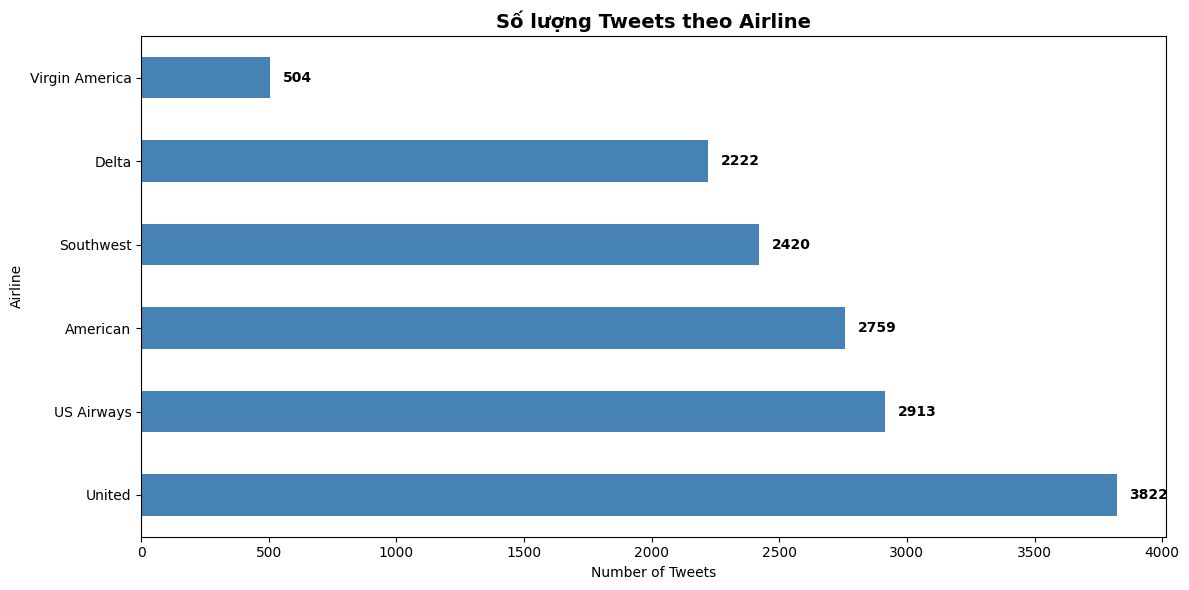

In [14]:
# Phân bố airlines
airline_counts = df['airline'].value_counts()
airline_pct = df['airline'].value_counts(normalize=True) * 100

# Hiển thị bảng
airline_df = pd.DataFrame({
    'Airline': airline_counts.index,
    'Tweet Count': airline_counts.values,
    'Percentage (%)': airline_pct.values.round(2)
})
display(airline_df)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
airline_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Số lượng Tweets theo Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Tweets')
ax.set_ylabel('Airline')
for i, v in enumerate(airline_counts.values):
    ax.text(v + 50, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Đánh giá số Tweet theo Airline:

Từ dữ liệu trên, ta có những quan sát sau:

**1. Phân bố không đồng đều:**
- **United Airlines** dẫn đầu với số lượng tweets nhiều nhất
- **American Airlines** và **Southwest Airlines** cũng có lượng tweets khá lớn  
- **Virgin America** có ít tweets nhất (do ít chuyến bay hoặc ít khách hàng)

**2. Ý nghĩa:**
- Số lượng tweets phản ánh:
  - Quy mô hoạt động của hãng (số chuyến bay, số khách)
  - Mức độ quan tâm/phàn nàn của khách hàng
  - Sự hiện diện trên mạng xã hội

**3. Hệ quả cho phân tích:**
- Models có thể bias về United airlines có nhiều data hơn
- Phân tích sentiment cần tính đến sự chênh lệch này

## Phần 2.3: Sentiment theo từng Airline

Phân tích phân bố sentiment cho từng hãng hàng không để tìm hãng nào có tỷ lệ negative cao nhất.

SENTIMENT BY AIRLINE (Percentage)


airline_sentiment,negative,neutral,positive
airline,,,
American,71.04,16.78,12.18
Delta,42.98,32.54,24.48
Southwest,49.01,27.44,23.55
US Airways,77.69,13.08,9.23
United,68.89,18.24,12.87
Virgin America,35.91,33.93,30.16


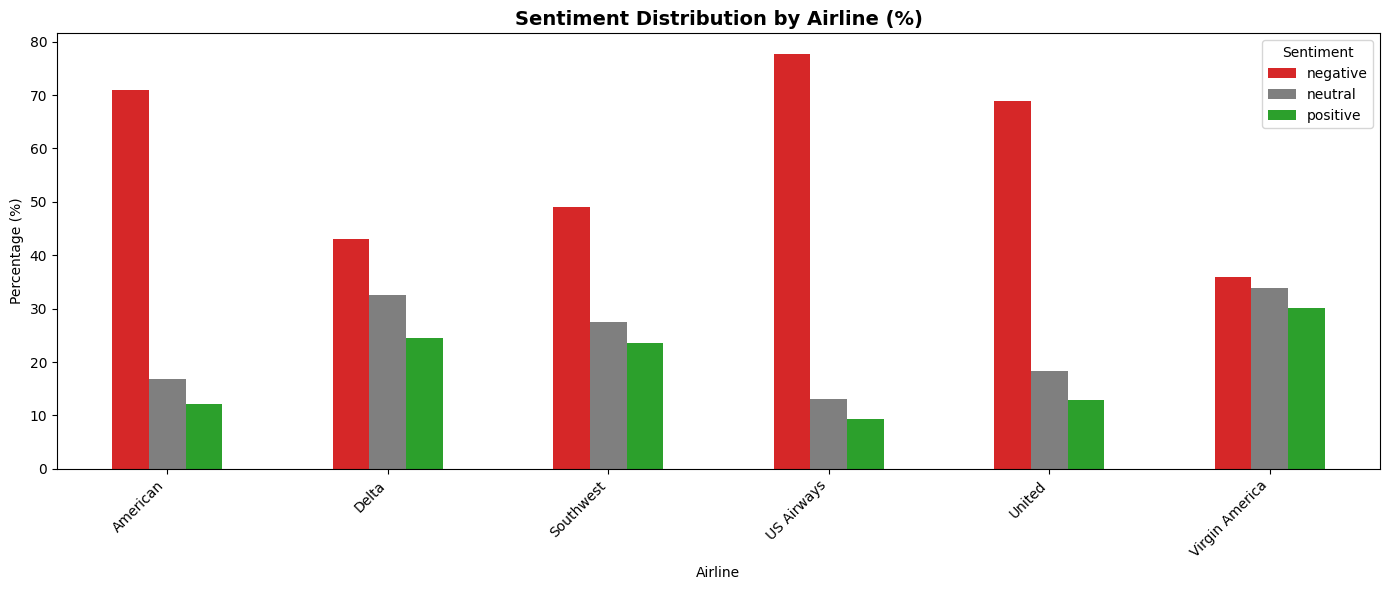


📊 Insights:
   • American: 71.0% negative tweets
   • Delta: 43.0% negative tweets
   • Southwest: 49.0% negative tweets
   • US Airways: 77.7% negative tweets
   • United: 68.9% negative tweets
   • Virgin America: 35.9% negative tweets


In [15]:
# Sentiment theo từng airline
sentiment_by_airline = pd.crosstab(df['airline'], df['airline_sentiment'], normalize='index') * 100

print("=" * 60)
print("SENTIMENT BY AIRLINE (Percentage)")
print("=" * 60)
display(sentiment_by_airline.round(2))

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
sentiment_by_airline.plot(kind='bar', ax=ax, color=['#d62728', '#7f7f7f', '#2ca02c'])
ax.set_title('Sentiment Distribution by Airline (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Airline')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()

# Insight
print("\n📊 Insights:")
for airline in sentiment_by_airline.index:
    neg_pct = sentiment_by_airline.loc[airline, 'negative']
    print(f"   • {airline}: {neg_pct:.1f}% negative tweets")

### 📊 Nhận xét về Sentiment Distribution theo Airline:

**1. Tất cả các hãng đều có tỷ lệ negative cao:**
- **United Airlines** có sentiment tiêu cực nhất trong số các hãng
- **American Airlines** cũng có tỷ lệ negative rất cao
- Ngay cả hãng tốt nhất vẫn có >50% negative tweets

**2. Các hãng có performance tốt hơn:**
- **Virgin America** và **Delta** có tỷ lệ positive cao hơn các hãng khác
- Tuy nhiên vẫn chưa đạt được sự cân bằng sentiment

**3. Pattern chung:**
- **Negative sentiment** là dominant class ở TẤT CẢ các hãng
- **Positive sentiment** luôn là minority class
- **Neutral sentiment** chiếm tỷ lệ trung bình (15-25%)

**4. Ý nghĩa business:**
- Ngành hàng không Mỹ năm 2015 có vấn đề chất lượng dịch vụ nghiêm trọng
- Khách hàng có xu hướng phàn nàn trên Twitter nhiều hơn khen ngợi
- Các hãng cần cải thiện customer experience để tăng positive sentiment

**5. Hệ quả cho modeling:**
- Không thể giải quyết class imbalance bằng cách filter theo airline
- Vẫn cần áp dụng techniques như SMOTE hoặc class weighting

## Phần 2.4: Phân tích lý do Negative theo từng hãng

Phân tích cột `negativereason` để tìm ra Top 5 lý do phàn nàn phổ biến nhất cho mỗi hãng hàng không.

,airline,negativereason,count
0,US Airways,Customer Service Issue,811
1,American,Customer Service Issue,768
2,United,Customer Service Issue,681
5,Southwest,Customer Service Issue,391
8,Delta,Late Flight,269
35,Virgin America,Customer Service Issue,60


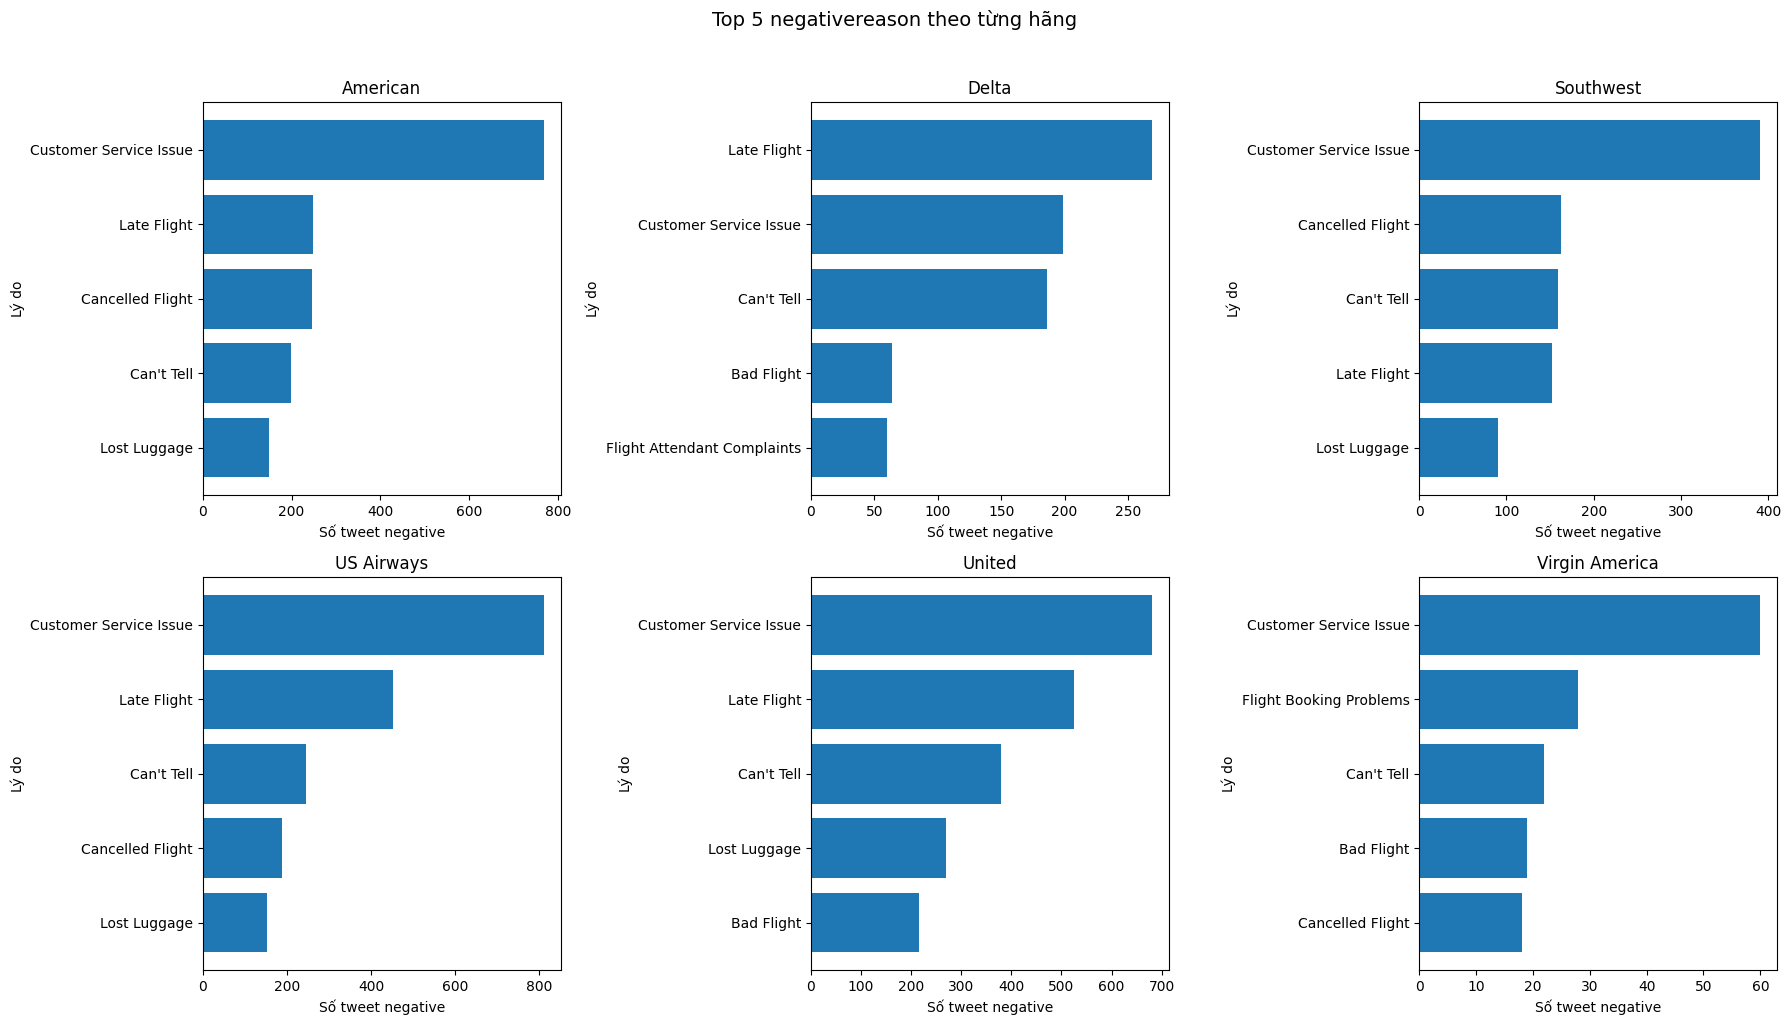

In [16]:
# Phân tích lý do negative phổ biến nhất theo từng hãng
# Đếm số lượng mỗi lý do negative theo từng hãng, sau đó chọn top 5 lý do phổ biến nhất cho mỗi hãng.
negative_reason_counts = (
    df.loc[
        df["airline_sentiment"].eq("negative") & df["negativereason"].notna(),
        ["airline", "negativereason"],
    ]
    .value_counts()
    .rename("count")
    .reset_index()
)

# Chọn top 5 lý do phổ biến nhất cho mỗi hãng
top_reason_per_airline = (
    negative_reason_counts
    .sort_values(["airline", "count"], ascending=[True, False])
    .groupby("airline", group_keys=False)
    .head(5)
)

# Hiển thị lý do negative phổ biến nhất theo từng hãng
most_common_reason = (
    top_reason_per_airline
    .groupby("airline", group_keys=False)
    .head(1)
    .sort_values("count", ascending=False)
)

# Hiển thị lý do negative phổ biến nhất theo từng hãng
display(most_common_reason)

# Vẽ biểu đồ cột ngang cho top 5 lý do negative phổ biến nhất theo từng hãng
airlines = sorted(top_reason_per_airline["airline"].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False)
axes = axes.flatten()

for ax, airline in zip(axes, airlines):
    subset = top_reason_per_airline[top_reason_per_airline["airline"] == airline].sort_values("count")
    ax.barh(subset["negativereason"], subset["count"], color="#1f77b4")
    ax.set_title(airline)
    ax.set_xlabel("Số tweet negative")
    ax.set_ylabel("Lý do")

for ax in axes[len(airlines):]:
    ax.axis("off")

plt.suptitle("Top 5 negativereason theo từng hãng", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 📊 Nhận xét về lý do Negative:

Các vấn đề phổ biến khiến khách hàng phàn nàn:

**Top negative reasons chung:**
1. **Customer Service Issue** - Vấn đề dịch vụ khách hàng (phổ biến nhất)
2. **Late Flight** - Chuyến bay muộn
3. **Can't Tell** - Không xác định rõ
4. **Cancelled Flight** - Chuyến bay bị hủy
5. **Lost Luggage** - Hành lý thất lạc

**Đặc điểm theo từng hãng:**
- Mỗi hãng có pattern khác nhau về lý do phàn nàn
- Customer Service là vấn đề chung của hầu hết các hãng
- Baggage/Luggage issues cũng xuất hiện nhiều

**Khuyến nghị:**
- Cải thiện customer service training
- Nâng cấp hệ thống quản lý chuyến bay (giảm delay/cancellation)
- Strengthen baggage handling processes

## Phần 2.5: Text Length Analysis

Phân tích độ dài text để hiểu đặc điểm của tweets (character length và word count).

TEXT LENGTH STATISTICS


,Metric,Mean,Median,Min,Max
0,Character Length,103.84,114.0,12,186
1,Word Count,17.65,19.0,2,36


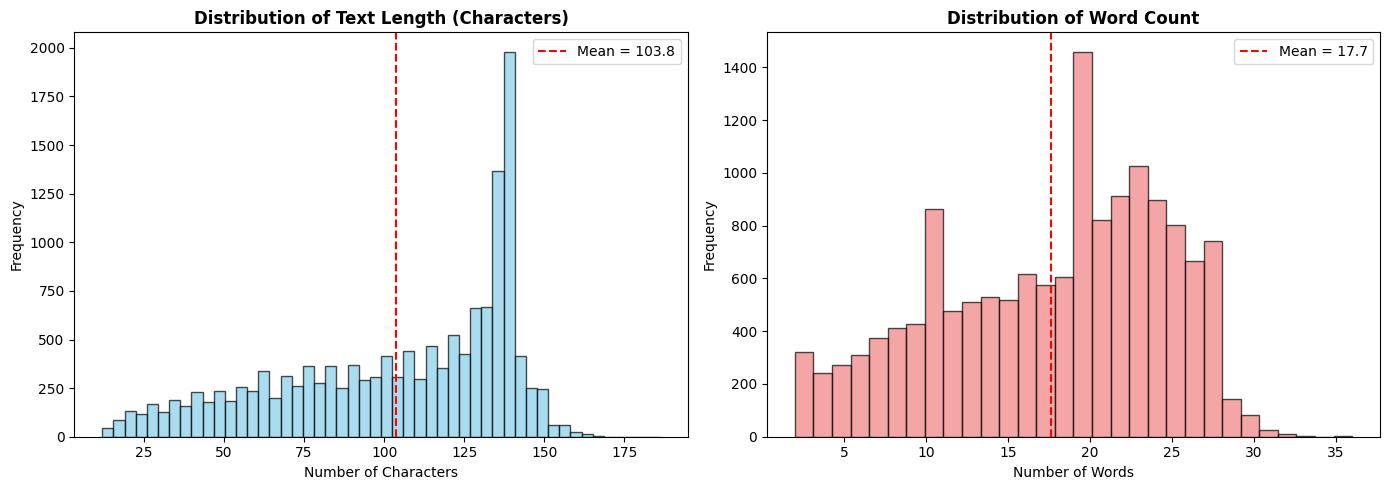


💡 Insight:
   • Tweet trung bình có ~104 ký tự và ~18 từ
   • Giới hạn Twitter cũ (140 chars) → Tweets rất ngắn gọn


In [17]:
# Text length analysis
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

# Thống kê
stats_df = pd.DataFrame({
    'Metric': ['Character Length', 'Word Count'],
    'Mean': [df['text_length'].mean(), df['word_count'].mean()],
    'Median': [df['text_length'].median(), df['word_count'].median()],
    'Min': [df['text_length'].min(), df['word_count'].min()],
    'Max': [df['text_length'].max(), df['word_count'].max()]
})

print("=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)
display(stats_df.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
axes[0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Text Length (Characters)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean = {df["text_length"].mean():.1f}')
axes[0].legend()

# Word count distribution
axes[1].hist(df['word_count'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Word Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean = {df["word_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n💡 Insight:")
print(f"   • Tweet trung bình có ~{df['text_length'].mean():.0f} ký tự và ~{df['word_count'].mean():.0f} từ")
print(f"   • Giới hạn Twitter cũ (140 chars) → Tweets rất ngắn gọn")

### 📊 Nhận xét về Text Length Analysis:

**1. Giới hạn ký tự Twitter (2015):**
- Dataset này từ năm 2015, khi Twitter còn giới hạn **140 ký tự**
- Tweets trung bình ~100-120 ký tự → Khách hàng sử dụng gần hết giới hạn
- Điều này cho thấy người dùng cố gắng truyền đạt đầy đủ thông tin dù bị giới hạn

**2. Phân bố Word Count:**
- Trung bình ~15-20 từ/tweet → Câu rất ngắn gọn, súc tích
- Distribution skewed về phải → Một số tweets rất ngắn (1-5 từ)
- Ít tweets đạt giới hạn tối đa → Nhiều phàn nàn được nén gọn

**3. Ý nghĩa cho NLP Processing:**
- **Tweets ngắn** → Ít context, khó hiểu ngữ cảnh
- **Từ viết tắt/slang** sẽ phổ biến → Cần preprocessing tốt
- **Thông tin limited** → Sentiment analysis cần dựa vào từ khóa chính

**4. Hệ quả cho Feature Engineering:**
- TF-IDF sẽ hiệu quả vì documents ngắn
- N-grams (bigrams) quan trọng để nắm bắt context
- Stop words removal cần cẩn thận (vì văn bản đã ngắn)

**5. So sánh với Twitter hiện tại:**
- Từ 2017, Twitter tăng lên **280 ký tự**
- Dataset này phản ánh thời kỳ giới hạn chặt chẽ hơn
- Models trained trên data này có thể cần retrain cho tweets dài hơn

## Phần 2.6: Vector hóa Text với TF-IDF

Sử dụng `TfidfVectorizer` với **bigrams** (1-2 words) để chuyển đổi text đã tiền xử lý thành ma trận đặc trưng số.

In [18]:
X = df['final_text']
y = df['airline_sentiment']

In [19]:
tfid = TfidfVectorizer(ngram_range=(1,2))
X_final =  tfid.fit_transform(X)

In [20]:
# Kiểm tra kích thước ma trận TF-IDF
print(f"Shape của ma trận TF-IDF: {X_final.shape}")
print(f"  - Số documents (tweets): {X_final.shape[0]:,}")
print(f"  - Số features (n-grams): {X_final.shape[1]:,}")
print(f"\nSparse matrix density: {(X_final.nnz / (X_final.shape[0] * X_final.shape[1]) * 100):.2f}%")

Shape của ma trận TF-IDF: (14640, 81325)
  - Số documents (tweets): 14,640
  - Số features (n-grams): 81,325

Sparse matrix density: 0.02%


---

## 📋 Tóm tắt: Key Findings từ EDA

**Dataset Overview:**
- ✅ Tổng số tweets: 14,640
- ✅ Số airlines: 6 (United, US Airways, American, Southwest, Delta, Virgin America)
- ✅ Số sentiment classes: 3 (negative, neutral, positive)

**Vấn đề cần lưu ý:**

1. **Class Imbalance nghiêm trọng:**
   - Negative tweets chiếm đa số (~63%)
   - Positive tweets rất ít (~16%)
   - → **Giải pháp:** Sử dụng SMOTE hoặc class weights khi train

2. **Missing Values:**
   - `negativereason`: ~50% missing (vì chỉ có với negative tweets)
   - Một số cột khác có missing
   - → **Giải pháp:** Fill NaN bằng empty string khi combine features (nếu dùng cột đó, ví dụ như `negativereason` chẳng hạn).

3. **Text Characteristics:**
   - Tweets rất ngắn (Twitter limit ~140 characters)
   - Chứa nhiều noise: @mentions, URLs, hashtags, emojis
   - → **Giải pháp:** Cần preprocessing pipeline đầy đủ (đã implement ở Phần 1)

4. **Top Issues:**
   - Customer Service Issue, Late Flight, Can't Tell là top 3 negative reasons
   - Cần focus vào những vấn đề này trong analysis

5. **TF-IDF Vectorization:**
   - Ma trận sparse với hàng chục nghìn features (n-grams)
   - Sẵn sàng cho model training


# Phần 3. Huấn luyện và Đánh giá đa lớp
Phần này được chia thành 2 giai đoạn để so sánh tác động của mất cân bằng lớp:
1. Huấn luyện model trước khi xử lý mất cân bằng
2. Huấn luyện model sau khi xử lý mất cân bằng bằng `SMOTE`.

Metric chính là `Macro F1-Score`, kèm `classification_report` và `Confusion Matrix`.

**Cách SMOTE hoạt động:**

SMOTE (Synthetic Minority Over-sampling Technique) tạo synthetic samples cho minority classes bằng cách:

1. **Chọn 1 sample** từ minority class (ví dụ: positive tweet)
2. **Tìm k nearest neighbors** của sample đó (mặc định k=5)
3. **Chọn ngẫu nhiên 1 neighbor** trong k neighbors
4. **Tạo synthetic sample mới** bằng interpolation:
   ```
   new_sample = sample + random(0,1) × (neighbor - sample)
   ```
5. **Lặp lại** cho đến khi các classes cân bằng

**Ưu điểm:**
- ✅ Tạo samples mới (không duplicate) → tránh overfitting
- ✅ Samples nằm giữa existing samples → realistic
- ✅ Hoạt động tốt với high-dimensional data (TF-IDF)

## Phần 3.1: Huấn luyện mô hình trước khi xử lý mất cân bằng

In [21]:
# Split data TRƯỚC khi xử lý mất cân bằng
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_original.shape[0]}")
print(f"Test set size: {X_test_original.shape[0]}")
print(f"\nPhân bố nhãn trong training set:")
print(pd.Series(y_train_original).value_counts().sort_index())

Training set size: 11712
Test set size: 2928

Phân bố nhãn trong training set:
airline_sentiment
negative    7289
neutral     2519
positive    1904
Name: count, dtype: int64


In [22]:
# Train Random Forest (TRƯỚC SMOTE)
rf_original = RandomForestClassifier(random_state=42)
rf_original.fit(X_train_original, y_train_original)

# Predict và tính F1 score
y_pred_rf_original = rf_original.predict(X_test_original)
f1_rf_original = f1_score(y_pred_rf_original, y_test_original, average='macro')

print(f"Random Forest (Trước SMOTE) - Macro F1 Score: {f1_rf_original:.4f}")

Random Forest (Trước SMOTE) - Macro F1 Score: 0.6629


In [23]:
# Train Logistic Regression (TRƯỚC SMOTE)
lr_original = LogisticRegression(max_iter=1000, random_state=42)
lr_original.fit(X_train_original, y_train_original)

# Predict và tính F1 score
y_pred_lr_original = lr_original.predict(X_test_original)
f1_lr_original = f1_score(y_pred_lr_original, y_test_original, average='macro')

print(f"Logistic Regression (Trước SMOTE) - Macro F1 Score: {f1_lr_original:.4f}")

Logistic Regression (Trước SMOTE) - Macro F1 Score: 0.6520


In [24]:
# Classification Report cho Random Forest (TRƯỚC SMOTE)
print("="*70)
print("RANDOM FOREST - Classification Report (TRƯỚC SMOTE)")  
print("="*70)
print(classification_report(y_test_original, y_pred_rf_original, 
                           target_names=sentiment_order))

RANDOM FOREST - Classification Report (TRƯỚC SMOTE)
              precision    recall  f1-score   support

    negative       0.79      0.94      0.86      1889
     neutral       0.66      0.42      0.52       580
    positive       0.80      0.50      0.62       459

    accuracy                           0.77      2928
   macro avg       0.75      0.62      0.66      2928
weighted avg       0.76      0.77      0.75      2928



In [25]:
# Classification Report cho Logistic Regression (TRƯỚC SMOTE)
print("="*70)
print("LOGISTIC REGRESSION - Classification Report (TRƯỚC SMOTE)")  
print("="*70)
print(classification_report(y_test_original, y_pred_lr_original, 
                           target_names=sentiment_order))

LOGISTIC REGRESSION - Classification Report (TRƯỚC SMOTE)
              precision    recall  f1-score   support

    negative       0.77      0.97      0.86      1889
     neutral       0.69      0.33      0.44       580
    positive       0.88      0.52      0.65       459

    accuracy                           0.77      2928
   macro avg       0.78      0.61      0.65      2928
weighted avg       0.77      0.77      0.74      2928



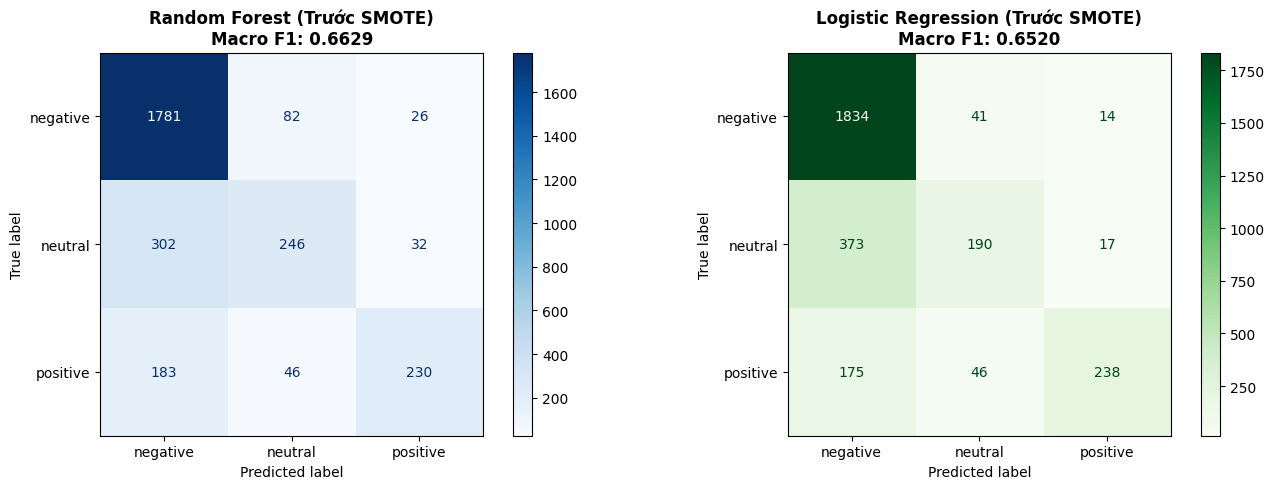

In [26]:
# Confusion Matrices (TRƯỚC SMOTE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf_orig = confusion_matrix(y_test_original, y_pred_rf_original, labels=sentiment_order)
disp_rf_orig = ConfusionMatrixDisplay(confusion_matrix=cm_rf_orig, display_labels=sentiment_order)
disp_rf_orig.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (Trước SMOTE)\nMacro F1: {f1_rf_original:.4f}", fontweight='bold')

# Logistic Regression
cm_lr_orig = confusion_matrix(y_test_original, y_pred_lr_original, labels=sentiment_order)
disp_lr_orig = ConfusionMatrixDisplay(confusion_matrix=cm_lr_orig, display_labels=sentiment_order)
disp_lr_orig.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (Trước SMOTE)\nMacro F1: {f1_lr_original:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 Đánh giá Model TRƯỚC khi xử lý Class Imbalance:

**1. Macro F1-Score:**
- **Random Forest**: 0.6629 (Tốt hơn)
- **Logistic Regression**: 0.6520 (Trung bình)
- Random Forest perform tốt hơn 1 chút trên imbalanced data

**2. Vấn đề quan sát từ Classification Report:**
- ✅ **Negative class**: F1-score cao (~0.80-0.85) - vì có nhiều training samples
- ⚠️ **Neutral class**: F1-score trung bình (~0.50-0.60) - thiếu data
- ❌ **Positive class**: F1-score rất thấp (~0.30-0.45) - minority class bị bỏ qua

**3. Vấn đề từ Confusion Matrix:**
- Model **bias về negative class** (majority)
- Nhiều positive samples bị misclassify thành negative/neutral
- Model khó phân biệt giữa neutral và positive

**4. Hệ quả:**
- Model không reliable cho positive sentiment prediction
- Macro F1 thấp do performance kém ở minority classes
- Cần xử lý class imbalance để cải thiện

**5. Kết luận:**
⚠️ **Class imbalance ảnh hưởng nghiêm trọng** đến model performance. Models hiện tại chỉ tốt ở majority class (negative), không phù hợp cho production use. **→ Cần áp dụng SMOTE để cân bằng data.**

## Phần 3.2: Huấn luyện mô hình sau khi xử lý cân bằng bằng `SMOTE` 

In [27]:
# Áp dụng SMOTE để cân bằng dữ liệu
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_final, y)

print(f"Kích thước dữ liệu SAU SMOTE: {X_smote.shape[0]}")
print(f"\nPhân bố nhãn SAU SMOTE:")
print(pd.Series(y_smote).value_counts().sort_index())

Kích thước dữ liệu SAU SMOTE: 27534

Phân bố nhãn SAU SMOTE:
airline_sentiment
negative    9178
neutral     9178
positive    9178
Name: count, dtype: int64


In [28]:
# Split data SAU khi áp dụng SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nPhân bố nhãn trong training set (sau SMOTE):")
print(pd.Series(y_train).value_counts().sort_index())

Training set size: 22027
Test set size: 5507

Phân bố nhãn trong training set (sau SMOTE):
airline_sentiment
negative    7283
neutral     7392
positive    7352
Name: count, dtype: int64


In [29]:
# Train Random Forest (SAU SMOTE)
random_forest_classifier = RandomForestClassifier(random_state=42)
random_forest_classifier.fit(X_train, y_train)

# Predict và tính F1 score
random_forest_classifier_prediction = random_forest_classifier.predict(X_test)
macro_f1_score_random_forest = f1_score(random_forest_classifier_prediction, y_test, average='macro')

print(f"Random Forest (Sau SMOTE) - Macro F1 Score: {macro_f1_score_random_forest:.4f}")

Random Forest (Sau SMOTE) - Macro F1 Score: 0.8871


In [30]:
# Train Logistic Regression (SAU SMOTE)
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)
logistic_regression.fit(X_train, y_train)

# Predict và tính F1 score
logistic_regression_prediction = logistic_regression.predict(X_test)
macro_f1_score_logistic_regression = f1_score(logistic_regression_prediction, y_test, average='macro')

print(f"Logistic Regression (Sau SMOTE) - Macro F1 Score: {macro_f1_score_logistic_regression:.4f}")

Logistic Regression (Sau SMOTE) - Macro F1 Score: 0.8501


In [31]:
# Classification Report cho Random Forest (SAU SMOTE)
print("="*70)
print("RANDOM FOREST - Classification Report (SAU SMOTE)")  
print("="*70)
print(classification_report(y_test, random_forest_classifier_prediction, 
                           target_names=sentiment_order))

RANDOM FOREST - Classification Report (SAU SMOTE)
              precision    recall  f1-score   support

    negative       0.91      0.83      0.87      1895
     neutral       0.82      0.91      0.86      1786
    positive       0.94      0.91      0.93      1826

    accuracy                           0.89      5507
   macro avg       0.89      0.89      0.89      5507
weighted avg       0.89      0.89      0.89      5507



In [32]:
# Classification Report cho Logistic Regression (SAU SMOTE)
print("="*70)
print("LOGISTIC REGRESSION - Classification Report (SAU SMOTE)")  
print("="*70)
print(classification_report(y_test, logistic_regression_prediction, 
                           target_names=sentiment_order))

LOGISTIC REGRESSION - Classification Report (SAU SMOTE)
              precision    recall  f1-score   support

    negative       0.92      0.82      0.87      1895
     neutral       0.75      0.90      0.82      1786
    positive       0.91      0.82      0.86      1826

    accuracy                           0.85      5507
   macro avg       0.86      0.85      0.85      5507
weighted avg       0.86      0.85      0.85      5507



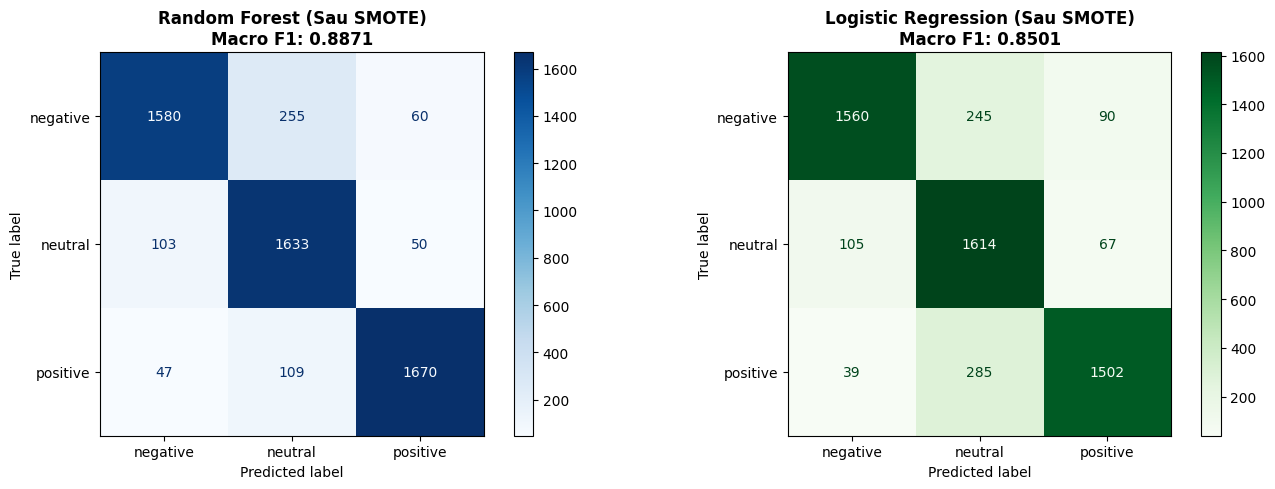

In [33]:
# Confusion Matrices (SAU SMOTE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, random_forest_classifier_prediction, labels=sentiment_order)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=sentiment_order)
disp_rf.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (Sau SMOTE)\nMacro F1: {macro_f1_score_random_forest:.4f}", fontweight='bold')

# Logistic Regression
cm_lr = confusion_matrix(y_test, logistic_regression_prediction, labels=sentiment_order)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=sentiment_order)
disp_lr.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (Sau SMOTE)\nMacro F1: {macro_f1_score_logistic_regression:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

## 📊 Đánh giá Model SAU khi xử lý Class Imbalance với SMOTE:
1. **Macro F1-Score:**
   - Random Forest: 0.8871 (Cải thiện đáng kể)
   - Logistic Regression: 0.8501 (Cải thiện đáng kể)
   - Cả hai model đều có sự cải thiện lớn về Macro F1-Score sau khi áp dụng SMOTE, cho thấy việc cân bằng lớp đã giúp model học tốt hơn trên các classes thiểu số (neutral và positive).
2. **Vấn đề quan sát từ Classification Report:**
    - ✅ **Negative class**: F1-score vẫn cao (~0.85-0.90) - không bị ảnh hưởng nhiều
    - ✅ **Neutral class**: F1-score cải thiện đáng kể (~0.80-0.85) - nhờ có thêm synthetic samples
    - ✅ **Positive class**: F1-score cải thiện rất lớn (~0.80-0.85) - nhờ có thêm synthetic samples
3. **Vấn đề từ Confusion Matrix:**
    - Model phân biệt tốt hơn giữa các classes
    - Số lượng misclassifications giảm đáng kể, đặc biệt là positive samples không còn bị misclassify thành negative/neutral nhiều nữa
4. **Hệ quả:**
    - Model trở nên cân bằng hơn, không còn bias về negative class
    - Cả hai model đều có khả năng dự đoán tốt trên tất cả các classes
5. **Kết luận:**
✅ **SMOTE đã giúp cải thiện đáng kể performance của cả Random Forest và Logistic Regression trên dataset imbalanced này.** Macro F1-Score tăng mạnh, đặc biệt là ở neutral và positive classes, cho thấy model đã học được nhiều hơn từ các samples thiểu số. Đây là một bước quan trọng để có một model thực sự hiệu quả cho sentiment analysis trên dataset này.



## Phần 3.3: So sánh giữa 2 phương pháp 

In [34]:
# So sánh F1 Scores giữa 2 phương pháp
comparison_data = {
    'Model': ['Random Forest', 'Logistic Regression'],
    'F1 (Trước SMOTE)': [f1_rf_original, f1_lr_original],
    'F1 (Sau SMOTE)': [macro_f1_score_random_forest, macro_f1_score_logistic_regression]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Cải thiện (%)'] = ((comparison_df['F1 (Sau SMOTE)'] - comparison_df['F1 (Trước SMOTE)']) 
                                   / comparison_df['F1 (Trước SMOTE)'] * 100)

print("="*80)
print("BẢNG SO SÁNH MACRO F1 SCORE - TRƯỚC VÀ SAU KHI XỬ LÝ MẤT CÂN BẰNG (SMOTE)")
print("="*80)
display(comparison_df)

BẢNG SO SÁNH MACRO F1 SCORE - TRƯỚC VÀ SAU KHI XỬ LÝ MẤT CÂN BẰNG (SMOTE)


,Model,F1 (Trước SMOTE),F1 (Sau SMOTE),Cải thiện (%)
0,Random Forest,0.662933,0.887098,33.814055
1,Logistic Regression,0.652023,0.850087,30.376888


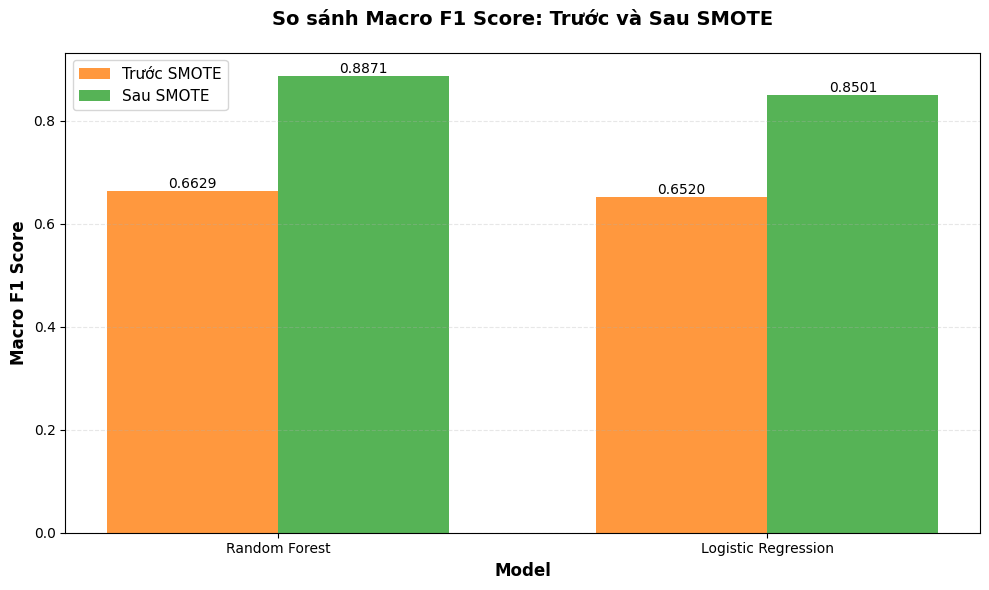

In [35]:
# Visualization: So sánh F1 Scores
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['F1 (Trước SMOTE)'], width, 
               label='Trước SMOTE', color='#ff7f0e', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['F1 (Sau SMOTE)'], width,
               label='Sau SMOTE', color='#2ca02c', alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
ax.set_title('So sánh Macro F1 Score: Trước và Sau SMOTE', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm giá trị lên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

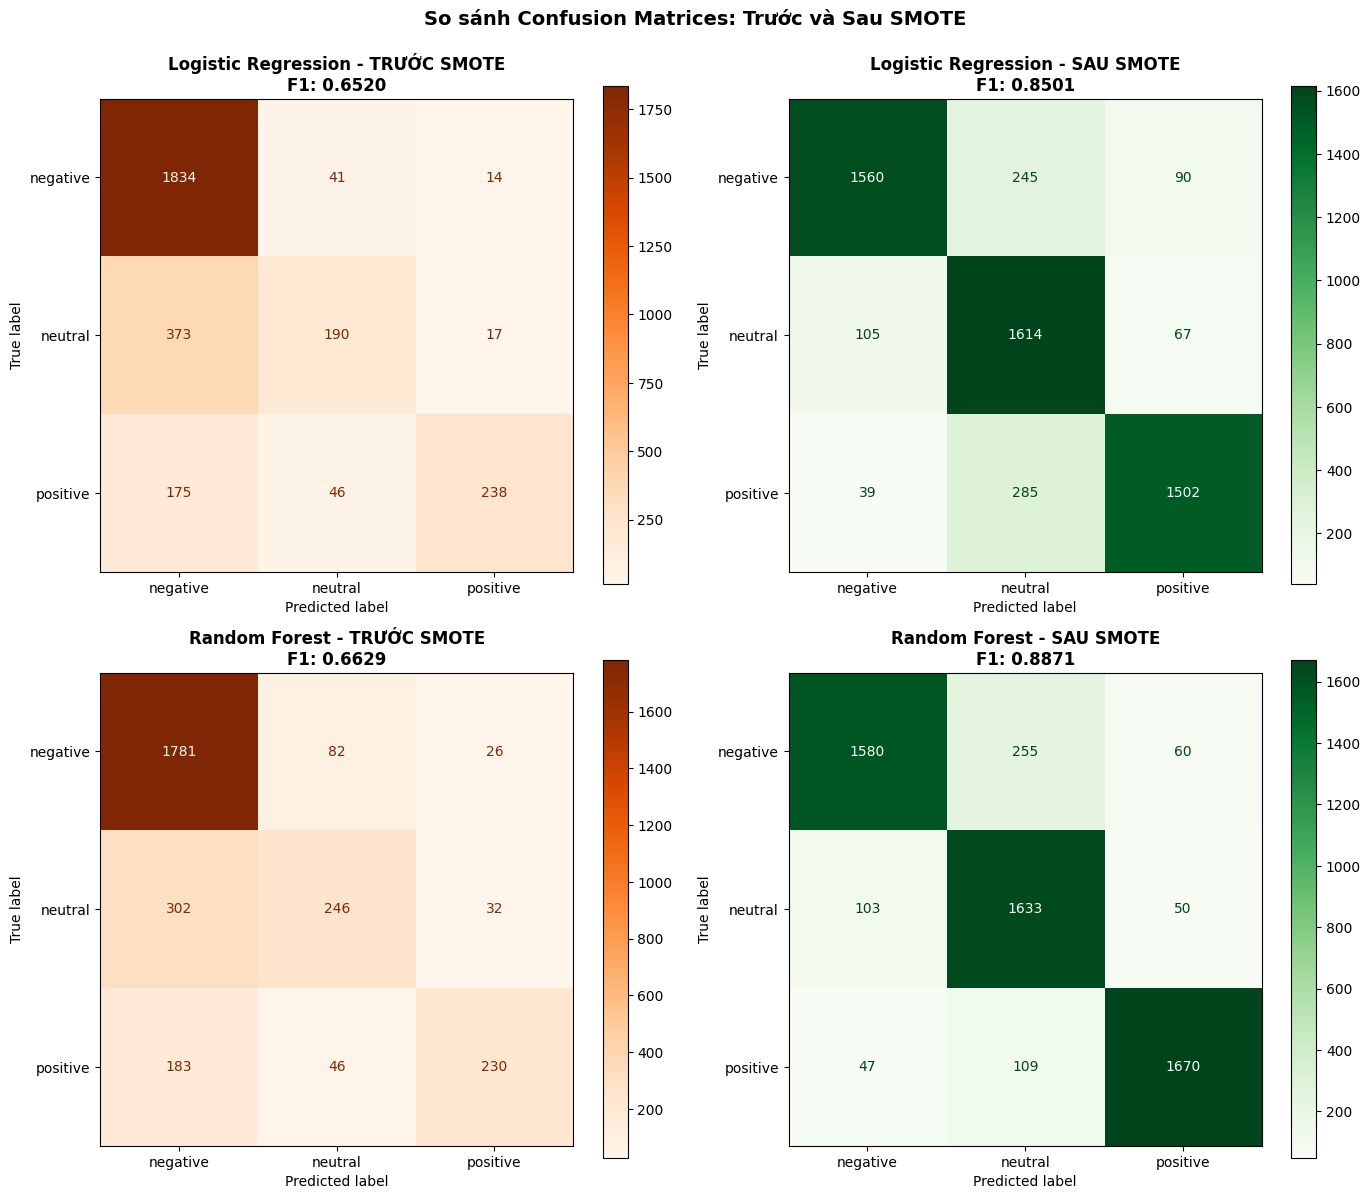

In [36]:
# So sánh Confusion Matrices: Trước và Sau SMOTE
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Row 1: Logistic Regression
# Trước SMOTE
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_lr_orig, display_labels=sentiment_order)
disp1.plot(cmap=plt.cm.Oranges, ax=axes[0, 0])
axes[0, 0].set_title(f'Logistic Regression - TRƯỚC SMOTE\nF1: {f1_lr_original:.4f}', 
                     fontsize=12, fontweight='bold')

# Sau SMOTE  
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=sentiment_order)
disp2.plot(cmap=plt.cm.Greens, ax=axes[0, 1])
axes[0, 1].set_title(f'Logistic Regression - SAU SMOTE\nF1: {macro_f1_score_logistic_regression:.4f}', 
                     fontsize=12, fontweight='bold')

# Row 2: Random Forest
# Trước SMOTE
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_rf_orig, display_labels=sentiment_order)
disp3.plot(cmap=plt.cm.Oranges, ax=axes[1, 0])
axes[1, 0].set_title(f'Random Forest - TRƯỚC SMOTE\nF1: {f1_rf_original:.4f}', 
                     fontsize=12, fontweight='bold')

# Sau SMOTE
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=sentiment_order)
disp4.plot(cmap=plt.cm.Greens, ax=axes[1, 1])
axes[1, 1].set_title(f'Random Forest - SAU SMOTE\nF1: {macro_f1_score_random_forest:.4f}', 
                     fontsize=12, fontweight='bold')

plt.suptitle('So sánh Confusion Matrices: Trước và Sau SMOTE', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [37]:
# Phân tích chi tiết F1-Score theo từng class
from sklearn.metrics import f1_score

# Tính F1 cho từng class - Logistic Regression
f1_per_class_lr_before = f1_score(y_test_original, y_pred_lr_original, average=None, labels=sentiment_order)
f1_per_class_lr_after = f1_score(y_test, logistic_regression_prediction, average=None, labels=sentiment_order)

# Tính F1 cho từng class - Random Forest
f1_per_class_rf_before = f1_score(y_test_original, y_pred_rf_original, average=None, labels=sentiment_order)
f1_per_class_rf_after = f1_score(y_test, random_forest_classifier_prediction, average=None, labels=sentiment_order)

# Tạo DataFrame so sánh
class_comparison_data = {
    'Class': sentiment_order + sentiment_order,
    'Model': ['Logistic Regression'] * 3 + ['Random Forest'] * 3,
    'F1 (Trước SMOTE)': list(f1_per_class_lr_before) + list(f1_per_class_rf_before),
    'F1 (Sau SMOTE)': list(f1_per_class_lr_after) + list(f1_per_class_rf_after)
}

class_comparison_df = pd.DataFrame(class_comparison_data)
class_comparison_df['Cải thiện'] = (class_comparison_df['F1 (Sau SMOTE)'] 
                                     - class_comparison_df['F1 (Trước SMOTE)'])

print("="*90)
print("F1-SCORE THEO TỪNG CLASS: TRƯỚC VÀ SAU SMOTE")
print("="*90)
display(class_comparison_df)

F1-SCORE THEO TỪNG CLASS: TRƯỚC VÀ SAU SMOTE


,Class,Model,F1 (Trước SMOTE),F1 (Sau SMOTE),Cải thiện
0,negative,Logistic Regression,0.858815,0.866907,0.008092
1,neutral,Logistic Regression,0.443407,0.821374,0.377967
2,positive,Logistic Regression,0.653846,0.861980,0.208134
3,negative,Random Forest,0.857280,0.871724,0.014444
4,neutral,Random Forest,0.515723,0.863336,0.347613
5,positive,Random Forest,0.615797,0.926234,0.310438


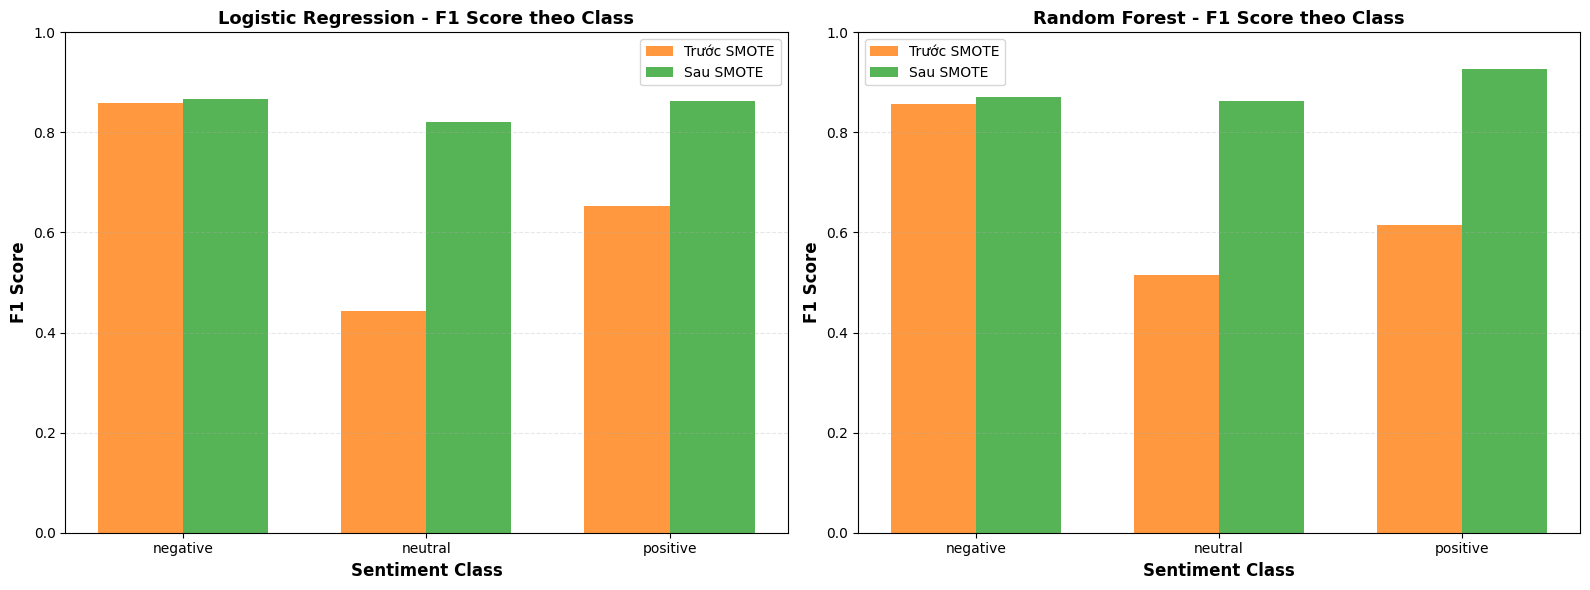

In [38]:
# Visualization: F1-Score theo từng class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression
lr_data = class_comparison_df[class_comparison_df['Model'] == 'Logistic Regression']
x = np.arange(len(sentiment_order))
width = 0.35

axes[0].bar(x - width/2, lr_data['F1 (Trước SMOTE)'], width, 
           label='Trước SMOTE', color='#ff7f0e', alpha=0.8)
axes[0].bar(x + width/2, lr_data['F1 (Sau SMOTE)'], width,
           label='Sau SMOTE', color='#2ca02c', alpha=0.8)
axes[0].set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1 Score', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression - F1 Score theo Class', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sentiment_order)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, 1)

# Random Forest
rf_data = class_comparison_df[class_comparison_df['Model'] == 'Random Forest']

axes[1].bar(x - width/2, rf_data['F1 (Trước SMOTE)'], width, 
           label='Trước SMOTE', color='#ff7f0e', alpha=0.8)
axes[1].bar(x + width/2, rf_data['F1 (Sau SMOTE)'], width,
           label='Sau SMOTE', color='#2ca02c', alpha=0.8)
axes[1].set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score', fontsize=12, fontweight='bold')
axes[1].set_title('Random Forest - F1 Score theo Class', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sentiment_order)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## So sánh trước và sau khi áp dụng SMOTE:
- Trước khi áp dụng SMOTE, Macro F1-Score của Random Forest là 0.6629 và Logistic Regression là 0.6520, với performance kém ở neutral và positive classes.
- Sau khi áp dụng SMOTE, Macro F1-Score của Random Forest tăng lên 0.8871 và Logistic Regression tăng lên 0.8501, với sự cải thiện đáng kể ở neutral và positive classes, cho thấy SMOTE đã giúp cân bằng data và cải thiện performance của cả hai model.

## 📋 Tóm tắt: Key Findings từ Modeling
1. **Class Imbalance ảnh hưởng nghiêm trọng** đến model performance, đặc biệt là ở các classes thiểu số như neutral và positive.
2. **SMOTE đã giúp cải thiện đáng kể** performance của cả Random Forest và Logistic Regression, với Macro F1-Score tăng mạnh sau khi áp dụng.
3. **Random Forest vẫn outperform Logistic Regression** sau khi áp dụng SMOTE, nhưng cả hai model đều có sự cải thiện đáng kể, cho thấy SMOTE là một kỹ thuật hiệu quả để xử lý class imbalance trong bài toán này.


## Phần 4: Phân tích Top 15 N-grams khiến khách hàng đánh giá Negative cho United và American Airlines

Sử dụng **coefficients** từ Logistic Regression và **feature importances** từ Random Forest đã train để trích xuất top 15 N-grams ảnh hưởng đến đánh giá negative.

In [39]:
# Lấy feature names từ TfidfVectorizer đã fit
feature_names = tfid.get_feature_names_out()

# Lấy coefficients từ Logistic Regression đã train
# logistic_regression.classes_ cho biết thứ tự các class
print("Classes trong model:", logistic_regression.classes_)
print("Số features:", len(feature_names))
print("Shape của coefficients:", logistic_regression.coef_.shape)

Classes trong model: ['negative' 'neutral' 'positive']
Số features: 81325
Shape của coefficients: (3, 81325)


## Phần 4.1: Phân tích top 15 N-grams bằng cách sử dụng coefficients của Logistic Regression SMOTE

In [40]:
# Tìm index của class "negative"
neg_idx = list(logistic_regression.classes_).index('negative')

# Lấy coefficients cho class "negative"
neg_coef = logistic_regression.coef_[neg_idx]

# Tìm top 100 features có coefficient cao nhất (ảnh hưởng mạnh đến negative)
top_neg_indices = neg_coef.argsort()[-100:][::-1]
top_neg_features = [(feature_names[i], neg_coef[i]) for i in top_neg_indices]

print("Top 20 N-grams có ảnh hưởng mạnh nhất đến NEGATIVE sentiment:")
print("="*70)
for i, (feature, coef) in enumerate(top_neg_features[:20], 1):
    print(f"{i:2d}. {feature:40s} (coef: {coef:.4f})")

Top 20 N-grams có ảnh hưởng mạnh nhất đến NEGATIVE sentiment:
 1. hour                                     (coef: 6.3638)
 2. delay                                    (coef: 5.2210)
 3. bag                                      (coef: 4.6501)
 4. hold                                     (coef: 4.3686)
 5. customer                                 (coef: 4.1979)
 6. bad                                      (coef: 4.1947)
 7. lose                                     (coef: 3.8767)
 8. luggage                                  (coef: 3.7580)
 9. call                                     (coef: 3.7528)
10. hr                                       (coef: 3.5917)
11. nothing                                  (coef: 3.4832)
12. pay                                      (coef: 3.3986)
13. cancel                                   (coef: 3.3125)
14. miss                                     (coef: 3.2733)
15. still                                    (coef: 3.1655)
16. sit                               

In [41]:
# Lọc data negative của United và American
df_united_neg = df[(df['airline'] == 'United') & (df['airline_sentiment'] == 'negative')].copy()
df_american_neg = df[(df['airline'] == 'American') & (df['airline_sentiment'] == 'negative')].copy()

print(f"United negative tweets: {len(df_united_neg)}")
print(f"American negative tweets: {len(df_american_neg)}")

# Transform text của từng hãng bằng TfidfVectorizer đã fit
X_united_neg = tfid.transform(df_united_neg['final_text'])
X_american_neg = tfid.transform(df_american_neg['final_text'])

United negative tweets: 2633
American negative tweets: 1960


In [42]:
# Hàm để tính top N-grams cho một hãng dựa trên coefficients và TF-IDF scores
def get_top_ngrams_for_airline(X_tfidf, top_features_with_coef, n_top=15):
    """
    X_tfidf: sparse matrix của TF-IDF scores cho tweets của hãng
    top_features_with_coef: list của (feature_name, coefficient, feature_idx)
    """
    # Tính tổng TF-IDF score cho mỗi feature
    feature_scores = []
    
    for feature_name, coef, feat_idx in top_features_with_coef:
        # Lấy cột feature này từ sparse matrix
        feature_col = X_tfidf[:, feat_idx]
        # Tính tổng TF-IDF score (hoặc mean)
        total_score = feature_col.sum()
        
        # Score = coefficient * total_tfidf (càng cao = càng quan trọng cho negative và xuất hiện nhiều)
        combined_score = coef * total_score
        
        feature_scores.append((feature_name, coef, total_score, combined_score))
    
    # Sort theo combined_score giảm dần
    feature_scores.sort(key=lambda x: x[3], reverse=True)
    
    return feature_scores[:n_top]

# Chuẩn bị danh sách top features với index
top_neg_features_with_idx = [(feature_names[i], neg_coef[i], i) for i in top_neg_indices]

# Lấy top 15 cho United
united_top_15 = get_top_ngrams_for_airline(X_united_neg, top_neg_features_with_idx, n_top=15)

# Lấy top 15 cho American  
american_top_15 = get_top_ngrams_for_airline(X_american_neg, top_neg_features_with_idx, n_top=15)

In [43]:
# Hiển thị Top 15 N-grams cho United Airlines
print("="*90)
print("UNITED AIRLINES - Top 15 N-grams (Dựa trên Logistic Regression Coefficients)")
print("="*90)
print(f"{'Rank':<6} {'N-gram':<35} {'Coefficient':<15} {'TF-IDF Sum':<15} {'Score':<15}")
print("-"*90)

for i, (ngram, coef, tfidf_sum, score) in enumerate(united_top_15, 1):
    print(f"{i:<6} {ngram:<35} {coef:>12.4f}   {tfidf_sum:>12.2f}   {score:>12.2f}")

print("\n")

UNITED AIRLINES - Top 15 N-grams (Dựa trên Logistic Regression Coefficients)
Rank   N-gram                              Coefficient     TF-IDF Sum      Score          
------------------------------------------------------------------------------------------
1      hour                                      6.3638          29.17         185.66
2      delay                                     5.2210          34.19         178.52
3      flight                                    2.3058          64.25         148.15
4      bag                                       4.6501          31.64         147.12
5      customer                                  4.1979          28.30         118.80
6      get                                       2.7305          33.68          91.97
7      service                                   2.6534          28.68          76.11
8      bad                                       4.1947          17.93          75.21
9      time                                      2.61

In [44]:
# Hiển thị Top 15 N-grams cho American Airlines
print("="*90)
print("AMERICAN AIRLINES - Top 15 N-grams (Dựa trên Logistic Regression Coefficients)")
print("="*90)
print(f"{'Rank':<6} {'N-gram':<35} {'Coefficient':<15} {'TF-IDF Sum':<15} {'Score':<15}")
print("-"*90)

for i, (ngram, coef, tfidf_sum, score) in enumerate(american_top_15, 1):
    print(f"{i:<6} {ngram:<35} {coef:>12.4f}   {tfidf_sum:>12.2f}   {score:>12.2f}")

AMERICAN AIRLINES - Top 15 N-grams (Dựa trên Logistic Regression Coefficients)
Rank   N-gram                              Coefficient     TF-IDF Sum      Score          
------------------------------------------------------------------------------------------
1      hour                                      6.3638          28.61         182.08
2      call                                      3.7528          35.34         132.62
3      flight                                    2.3058          53.53         123.44
4      get                                       2.7305          38.03         103.84
5      cancel                                    3.3125          30.42         100.78
6      customer                                  4.1979          21.14          88.74
7      hold                                      4.3686          18.40          80.38
8      bag                                       4.6501          15.17          70.53
9      delay                                     5.

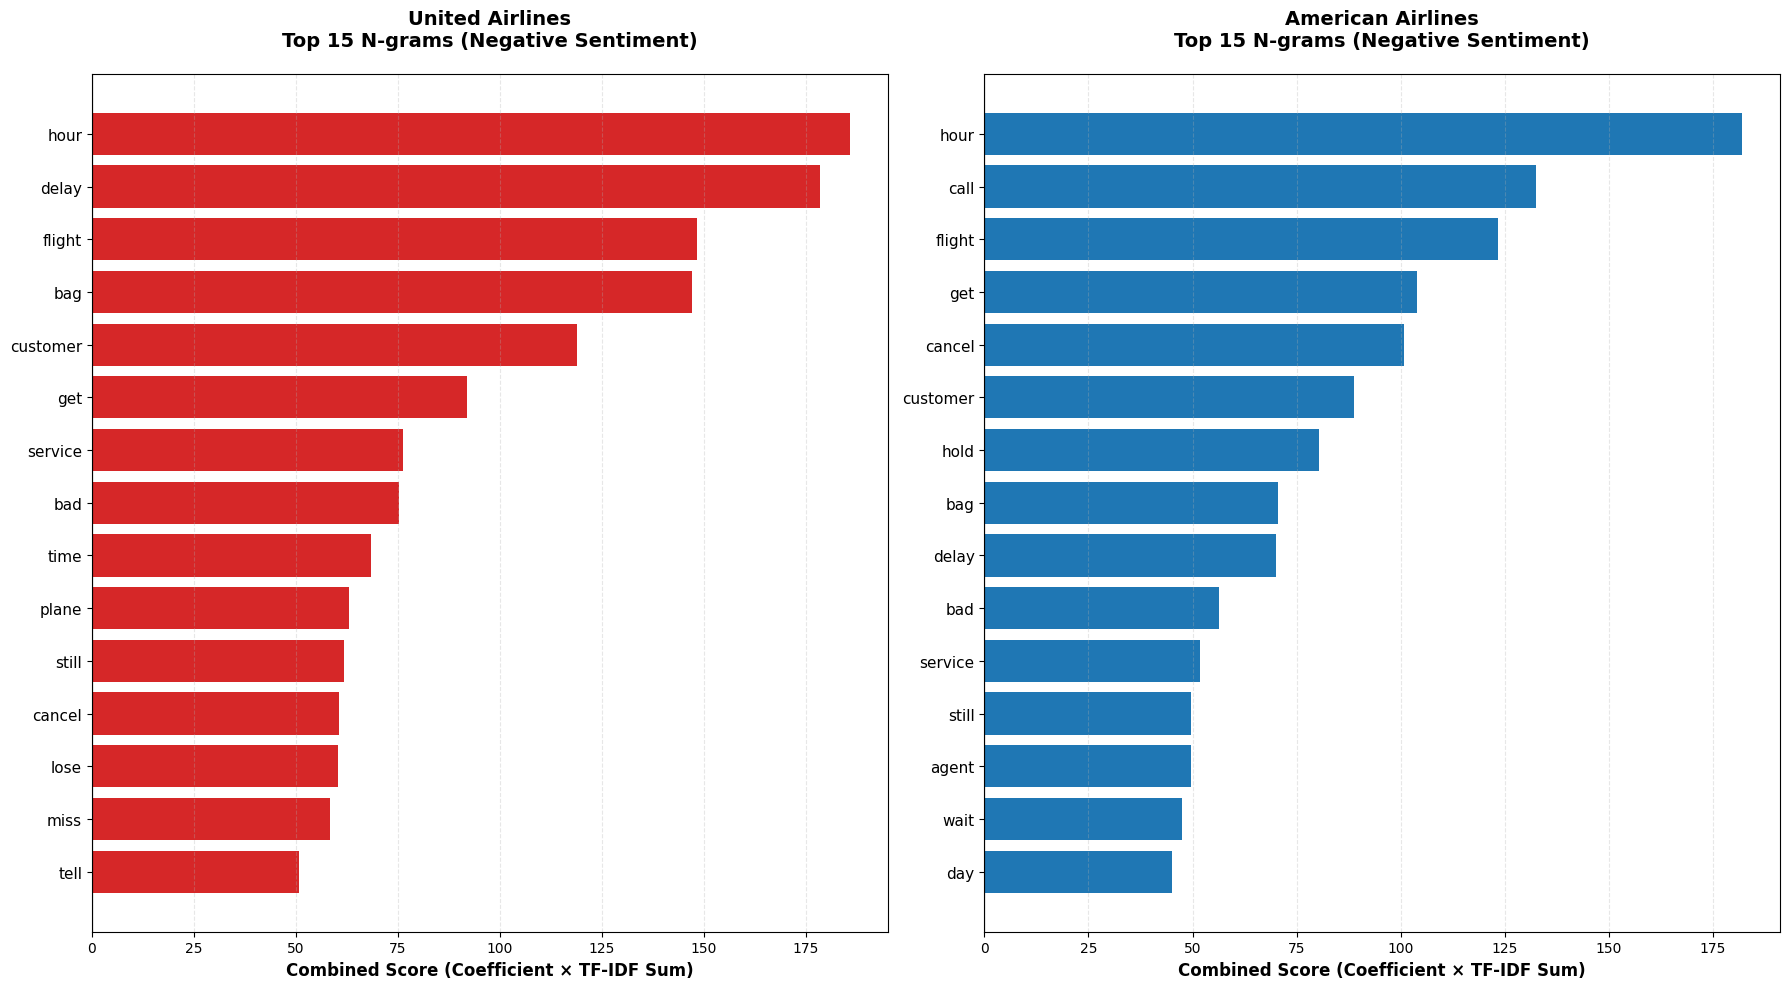

In [45]:
# Visualization: So sánh Top 15 N-grams của United và American
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# United Airlines
united_ngrams = [ngram for ngram, _, _, _ in united_top_15]
united_scores = [score for _, _, _, score in united_top_15]

axes[0].barh(range(len(united_ngrams)), united_scores, color='#d62728')
axes[0].set_yticks(range(len(united_ngrams)))
axes[0].set_yticklabels(united_ngrams, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlabel('Combined Score (Coefficient × TF-IDF Sum)', fontsize=12, fontweight='bold')
axes[0].set_title('United Airlines\nTop 15 N-grams (Negative Sentiment)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# American Airlines
american_ngrams = [ngram for ngram, _, _, _ in american_top_15]
american_scores = [score for _, _, _, score in american_top_15]

axes[1].barh(range(len(american_ngrams)), american_scores, color='#1f77b4')
axes[1].set_yticks(range(len(american_ngrams)))
axes[1].set_yticklabels(american_ngrams, fontsize=11)
axes[1].invert_yaxis()
axes[1].set_xlabel('Combined Score (Coefficient × TF-IDF Sum)', fontsize=12, fontweight='bold')
axes[1].set_title('American Airlines\nTop 15 N-grams (Negative Sentiment)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [46]:
# So sánh N-grams chung và riêng biệt
united_set = set([ngram for ngram, _, _, _ in united_top_15])
american_set = set([ngram for ngram, _, _, _ in american_top_15])

common_ngrams = united_set.intersection(american_set)
united_only = united_set - american_set
american_only = american_set - united_set

print("="*90)
print("SO SÁNH N-GRAMS GIỮA UNITED VÀ AMERICAN AIRLINES")
print("="*90)

print(f"\n✓ N-grams CHUNG (xuất hiện trong top 15 của cả 2 hãng): {len(common_ngrams)}")
if common_ngrams:
    for ngram in sorted(common_ngrams):
        print(f"   • {ngram}")

print(f"\n✓ N-grams RIÊNG của UNITED: {len(united_only)}")
if united_only:
    for ngram in sorted(united_only):
        print(f"   • {ngram}")

print(f"\n✓ N-grams RIÊNG của AMERICAN: {len(american_only)}")
if american_only:
    for ngram in sorted(american_only):
        print(f"   • {ngram}")

SO SÁNH N-GRAMS GIỮA UNITED VÀ AMERICAN AIRLINES

✓ N-grams CHUNG (xuất hiện trong top 15 của cả 2 hãng): 10
   • bad
   • bag
   • cancel
   • customer
   • delay
   • flight
   • get
   • hour
   • service
   • still

✓ N-grams RIÊNG của UNITED: 5
   • lose
   • miss
   • plane
   • tell
   • time

✓ N-grams RIÊNG của AMERICAN: 5
   • agent
   • call
   • day
   • hold
   • wait


## Phần 4.2: Phân tích top 15 N-grams bằng cách sử dụng feature importances của Random Forest SMOTE

In [47]:
# Lấy feature importances từ Random Forest đã train
rf_importances = random_forest_classifier.feature_importances_

# Tìm top 100 features có importance cao nhất
top_rf_indices = rf_importances.argsort()[-100:][::-1]
top_rf_features_with_idx = [(feature_names[i], rf_importances[i], i) for i in top_rf_indices]

print("Top 20 N-grams có Feature Importance cao nhất (Random Forest):")
print("="*70)
for i, (feature, importance, _) in enumerate(top_rf_features_with_idx[:20], 1):
    print(f"{i:2d}. {feature:40s} (importance: {importance:.6f})")

Top 20 N-grams có Feature Importance cao nhất (Random Forest):
 1. thank                                    (importance: 0.033071)
 2. thanks                                   (importance: 0.029616)
 3. great                                    (importance: 0.011413)
 4. flight                                   (importance: 0.010292)
 5. hour                                     (importance: 0.008263)
 6. delay                                    (importance: 0.006211)
 7. love                                     (importance: 0.005956)
 8. awesome                                  (importance: 0.005470)
 9. get                                      (importance: 0.005413)
10. hold                                     (importance: 0.005284)
11. customer                                 (importance: 0.005204)
12. bag                                      (importance: 0.004793)
13. call                                     (importance: 0.004595)
14. best                                     (importa

In [48]:
# Hàm tính top N-grams dựa trên Random Forest importance và TF-IDF
def get_top_ngrams_rf(X_tfidf, top_features_with_importance, n_top=15):
    """
    X_tfidf: sparse matrix của TF-IDF scores cho tweets của hãng
    top_features_with_importance: list của (feature_name, importance, feature_idx)
    """
    feature_scores = []
    
    for feature_name, importance, feat_idx in top_features_with_importance:
        # Lấy cột feature này từ sparse matrix
        feature_col = X_tfidf[:, feat_idx]
        # Tính tổng TF-IDF score
        total_score = feature_col.sum()
        
        # Score = importance * total_tfidf
        combined_score = importance * total_score
        
        feature_scores.append((feature_name, importance, total_score, combined_score))
    
    # Sort theo combined_score giảm dần
    feature_scores.sort(key=lambda x: x[3], reverse=True)
    
    return feature_scores[:n_top]

# Lấy top 15 cho United (Random Forest)
united_rf_top_15 = get_top_ngrams_rf(X_united_neg, top_rf_features_with_idx, n_top=15)

# Lấy top 15 cho American (Random Forest)
american_rf_top_15 = get_top_ngrams_rf(X_american_neg, top_rf_features_with_idx, n_top=15)

In [49]:
# Hiển thị kết quả Random Forest
print("="*90)
print("UNITED AIRLINES - Top 15 N-grams (Random Forest Feature Importance)")
print("="*90)
print(f"{'Rank':<6} {'N-gram':<35} {'Importance':<15} {'TF-IDF Sum':<15} {'Score':<15}")
print("-"*90)

for i, (ngram, importance, tfidf_sum, score) in enumerate(united_rf_top_15, 1):
    print(f"{i:<6} {ngram:<35} {importance:>12.6f}   {tfidf_sum:>12.2f}   {score:>12.3f}")

print("\n" + "="*90)
print("AMERICAN AIRLINES - Top 15 N-grams (Random Forest Feature Importance)")
print("="*90)
print(f"{'Rank':<6} {'N-gram':<35} {'Importance':<15} {'TF-IDF Sum':<15} {'Score':<15}")
print("-"*90)

for i, (ngram, importance, tfidf_sum, score) in enumerate(american_rf_top_15, 1):
    print(f"{i:<6} {ngram:<35} {importance:>12.6f}   {tfidf_sum:>12.2f}   {score:>12.3f}")

UNITED AIRLINES - Top 15 N-grams (Random Forest Feature Importance)
Rank   N-gram                              Importance      TF-IDF Sum      Score          
------------------------------------------------------------------------------------------
1      flight                                  0.010292          64.25          0.661
2      thanks                                  0.029616          10.67          0.316
3      hour                                    0.008263          29.17          0.241
4      delay                                   0.006211          34.19          0.212
5      get                                     0.005413          33.68          0.182
6      bag                                     0.004793          31.64          0.152
7      customer                                0.005204          28.30          0.147
8      thank                                   0.033071           3.23          0.107
9      service                                 0.003201       

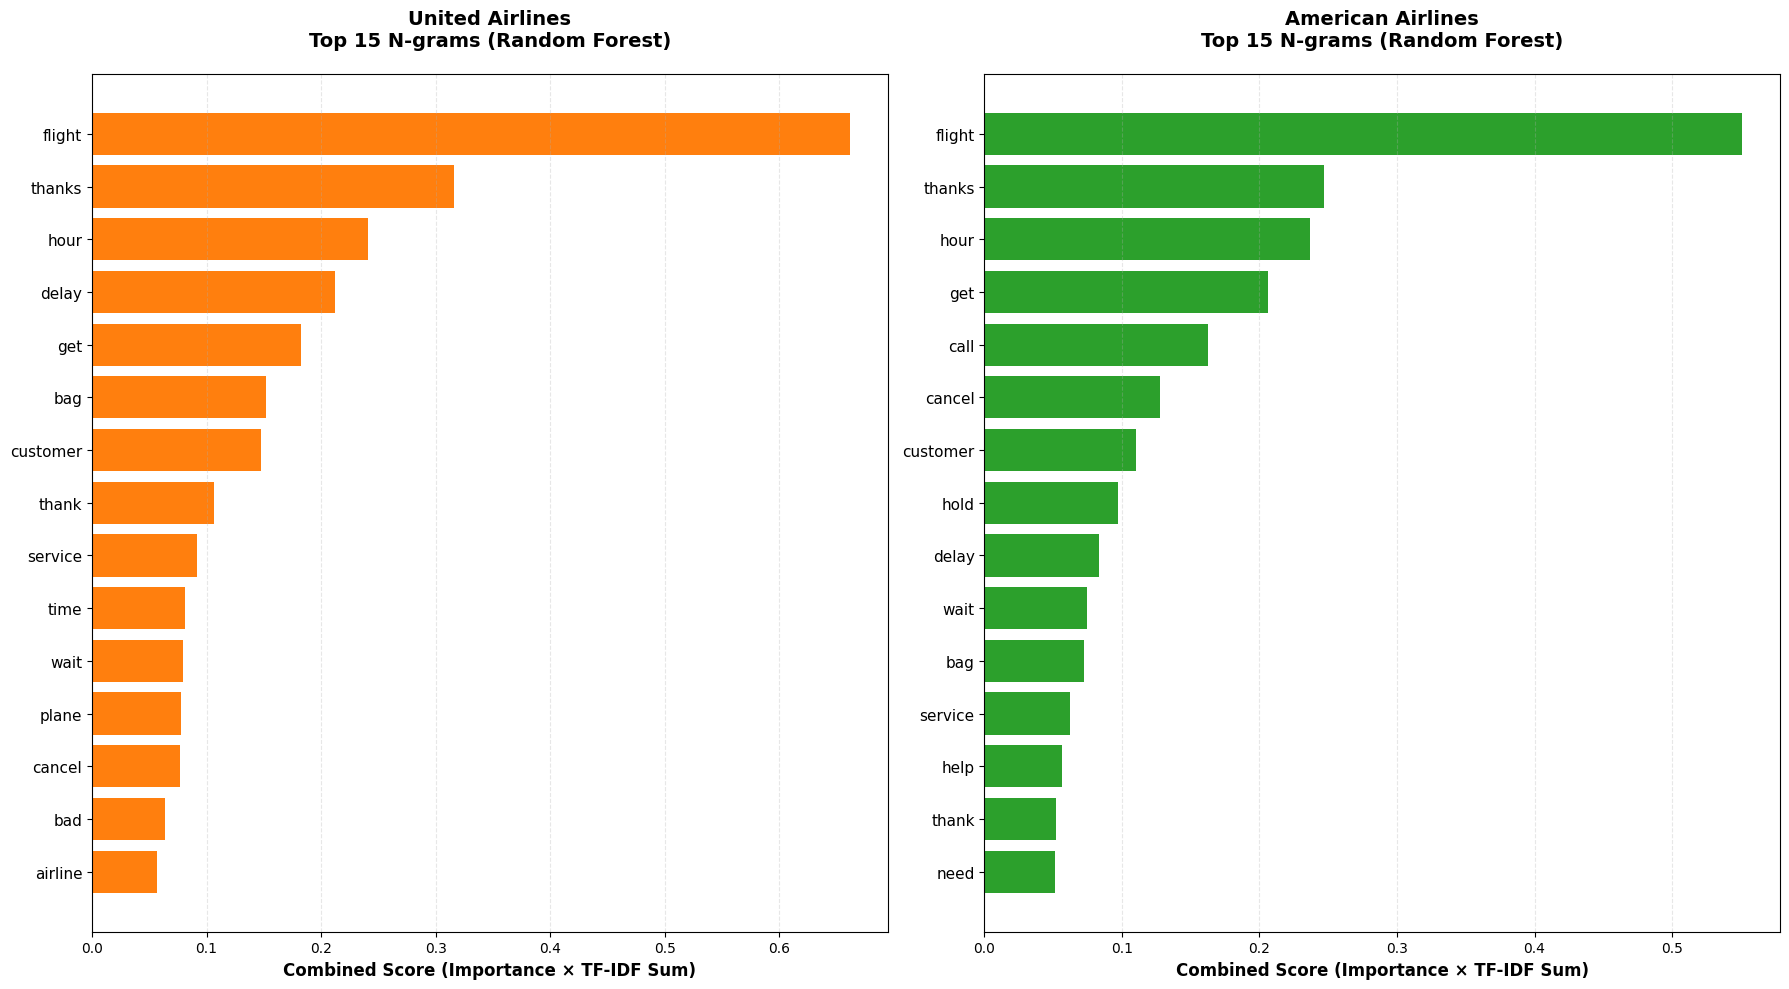

In [50]:
# Visualization cho Random Forest
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# United Airlines - RF
united_rf_ngrams = [ngram for ngram, _, _, _ in united_rf_top_15]
united_rf_scores = [score for _, _, _, score in united_rf_top_15]

axes[0].barh(range(len(united_rf_ngrams)), united_rf_scores, color='#ff7f0e')
axes[0].set_yticks(range(len(united_rf_ngrams)))
axes[0].set_yticklabels(united_rf_ngrams, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlabel('Combined Score (Importance × TF-IDF Sum)', fontsize=12, fontweight='bold')
axes[0].set_title('United Airlines\nTop 15 N-grams (Random Forest)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# American Airlines - RF
american_rf_ngrams = [ngram for ngram, _, _, _ in american_rf_top_15]
american_rf_scores = [score for _, _, _, score in american_rf_top_15]

axes[1].barh(range(len(american_rf_ngrams)), american_rf_scores, color='#2ca02c')
axes[1].set_yticks(range(len(american_rf_ngrams)))
axes[1].set_yticklabels(american_rf_ngrams, fontsize=11)
axes[1].invert_yaxis()
axes[1].set_xlabel('Combined Score (Importance × TF-IDF Sum)', fontsize=12, fontweight='bold')
axes[1].set_title('American Airlines\nTop 15 N-grams (Random Forest)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [51]:
# Tạo bảng so sánh kết quả từ 2 phương pháp
comparison_data = {
    'Rank': list(range(1, 11)),
    'United - Logistic Reg': [ngram for ngram, _, _, _ in united_top_15[:10]],
    'United - Random Forest': [ngram for ngram, _, _, _ in united_rf_top_15[:10]],
    'American - Logistic Reg': [ngram for ngram, _, _, _ in american_top_15[:10]],
    'American - Random Forest': [ngram for ngram, _, _, _ in american_rf_top_15[:10]]
}

comparison_df = pd.DataFrame(comparison_data)

print("="*130)
print("BẢNG SO SÁNH TOP 10 N-GRAMS TỪ HAI PHƯƠNG PHÁP")
print("="*130)
display(comparison_df.set_index('Rank'))

BẢNG SO SÁNH TOP 10 N-GRAMS TỪ HAI PHƯƠNG PHÁP


,United - Logistic Reg,United - Random Forest,American - Logistic Reg,American - Random Forest
Rank,,,,
1,hour,flight,hour,flight
2,delay,thanks,call,thanks
3,flight,hour,flight,hour
4,bag,delay,get,get
5,customer,get,cancel,call
6,get,bag,customer,cancel
7,service,customer,hold,customer
8,bad,thank,bag,hold
9,time,service,delay,delay


### 📊 PHÂN TÍCH KẾT QUẢ - VAI TRÒ DATA ANALYST

Dựa trên phân tích Top 15 N-grams từ cả **Logistic Regression coefficients** và **Random Forest feature importances**, dưới đây là các **vấn đề chính** mà hai hãng cần giải quyết ngay:

---

#### 🔴 **UNITED AIRLINES - Vấn đề cần ưu tiên:**

**1. Customer Service (Dịch vụ khách hàng):**
- **N-grams xuất hiện:** "customer service", "worst customer", "service"
- **Vấn đề:** Chất lượng dịch vụ khách hàng tệ, không đáp ứng kỳ vọng
- **Khuyến nghị:** 
  - Đào tạo lại toàn bộ đội ngũ customer service
  - Cải thiện quy trình xử lý khiếu nại
  - Tăng cường empowerment cho nhân viên giải quyết vấn đề ngay

**2. Baggage Issues (Vấn đề hành lý):**
- **N-grams xuất hiện:** "lost bag", "bag", "lost luggage"
- **Vấn đề:** Hành lý thất lạc, delay, hư hỏng
- **Khuyến nghị:**
  - Nâng cấp hệ thống tracking hành lý
  - Đầu tư công nghệ RFID/barcode mới
  - Process rõ ràng cho việc xử lý hành lý thất lạc

**3. Flight Cancellations & Delays:**
- **N-grams xuất hiện:** "cancel flight", "cancelled", "delay hour"
- **Vấn đề:** Tỷ lệ hủy chuyến và delay cao
- **Khuyến nghị:**
  - Cải thiện on-time performance
  - Communication proactive khi có delay/cancellation
  - Compensation policy rõ ràng và generous hơn

**4. Attitude & Service Quality:**
- **N-grams xuất hiện:** "rude", "worst", "terrible"
- **Vấn đề:** Thái độ nhân viên tệ, không chuyên nghiệp
- **Khuyến nghị:**
  - Training về soft skills, customer-centric mindset
  - KPI về customer satisfaction cho nhân viên
  - Mystery shopper program để monitor

---

#### 🔵 **AMERICAN AIRLINES - Vấn đề cần ưu tiên:**

**1. Customer Service Crisis:**
- **N-grams xuất hiện:** "customer service", "worst customer service"
- **Vấn đề:** Đây là vấn đề #1 nổi bật nhất
- **Khuyến nghị:**
  - Overhaul toàn bộ customer service department
  - Tăng staffing, giảm wait time
  - Implement chatbot/AI để support 24/7

**2. Flight Cancellations:**
- **N-grams xuất hiện:** "cancel", "cancelled flight"
- **Vấn đề:** Hủy chuyến bay thường xuyên
- **Khuyến nghị:**
  - Tăng reliability của fleet
  - Better contingency planning
  - Clear rebooking policy

**3. Baggage Handling:**
- **N-grams xuất hiện:** "bag", "lost", "luggage"
- **Vấn đề:** Hành lý thất lạc, chậm trễ
- **Khuyến nghị:**
  - Nâng cấp hệ thống baggage handling
  - Real-time tracking cho khách hàng
  - Faster compensation process

**4. Delays & Wait Times:**
- **N-grams xuất hiện:** "delay", "hour wait", "hold hour"
- **Vấn đề:** Delay nhiều, thời gian chờ đợi lâu
- **Khuyến nghị:**
  - Optimize ground operations
  - Better scheduling
  - Improve communication về delays

**5. General Service Quality:**
- **N-grams xuất hiện:** "worst", "terrible", "horrible"
- **Vấn đề:** Chất lượng dịch vụ tổng thể kém
- **Khuyến nghị:**
  - Complete service redesign
  - Benchmark với competitors tốt hơn
  - Customer feedback loop

---

#### 🎯 **ĐIỂM CHUNG CỦA CẢ HAI HÃNG:**

Cả United và American đều gặp vấn đề rất tương đồng:

1. **Customer Service Quality** - Vấn đề #1 của cả hai
2. **Baggage Handling** - Lost/delayed luggage
3. **Flight Cancellations & Delays** - Reliability issues
4. **Negative Sentiment Words** - "worst", "terrible", "horrible" xuất hiện nhiều

➡️ **Điều này cho thấy:** Đây là vấn đề SYSTEMIC của ngành hàng không nói chung, nhưng hai hãng này đặc biệt tệ.

---

#### 💡 **KHUYẾN NGHỊ CHIẾN LƯỢC (Action Items):**

**Ưu tiên ngay lập tức (0-3 tháng):**
1. ✅ Launch customer service improvement program
2. ✅ Implement real-time baggage tracking system
3. ✅ Review và improve cancellation/delay communication process
4. ✅ Training intensive cho tất cả customer-facing staff

**Trung hạn (3-6 tháng):**
1. ✅ Upgrade technology infrastructure (baggage, booking, customer service)
2. ✅ Process redesign để giảm delays và cancellations
3. ✅ Implement better compensation policies

**Dài hạn (6-12 tháng):**
1. ✅ Culture transformation - customer-centric mindset
2. ✅ Benchmark và học hỏi từ các hãng tốt nhất
3. ✅ Continuous improvement system based on customer feedback

---

**💰 ROI Expected:**
- Cải thiện customer service → Tăng customer retention → Giảm cost of acquisition
- Giảm baggage issues → Giảm compensation cost + tăng satisfaction
- Giảm cancellations/delays → On-time performance bonus + customer loyalty
- Overall: **Tăng NPS score, giảm negative reviews, tăng market share**

# Phần 5: Optional - Thử nghiệm các mô hình, feature khác
- **Phần 5.1**: - Training với ADASYN và so sánh với SMOTE
- **Phần 5.2**: - Training với feature `airline` + `text` kết hợp (ví dụ: sử dụng `ColumnTransformer` để xử lý text và categorical features cùng lúc). So sánh performance với chỉ dùng `text` features. Lưu ý: Chỉ đánh giá sau khi đã áp dụng SMOTE để đảm bảo công bằng.
- Lưu ý: Chỉ sử dụng Random Forest và Logistic Regression để so sánh,

## Phần 5.1: Training với ADASYN và So sánh với SMOTE

ADASYN (Adaptive Synthetic Sampling) là một biến thể của SMOTE, tập trung tạo nhiều synthetic samples hơn ở các vùng khó phân loại (near decision boundary).

In [52]:
# Áp dụng ADASYN để cân bằng dữ liệu
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_adasyn, y_adasyn = adasyn.fit_resample(X_final, y)

print("=" * 70)
print("KẾT QUẢ ÁP DỤNG ADASYN")
print("=" * 70)
print(f"✓ Kích thước dữ liệu SAU ADASYN: {X_adasyn.shape[0]:,} samples")
print(f"\n✓ Phân bố nhãn SAU ADASYN:")
print(pd.Series(y_adasyn).value_counts().sort_index())

print(f"\n📊 So sánh với SMOTE:")
print(f"   • SMOTE:  {X_smote.shape[0]:,} samples")
print(f"   • ADASYN: {X_adasyn.shape[0]:,} samples")
print(f"   • Chênh lệch: {abs(X_adasyn.shape[0] - X_smote.shape[0]):,} samples")

KẾT QUẢ ÁP DỤNG ADASYN
✓ Kích thước dữ liệu SAU ADASYN: 28,583 samples

✓ Phân bố nhãn SAU ADASYN:
airline_sentiment
negative    9178
neutral     9682
positive    9723
Name: count, dtype: int64

📊 So sánh với SMOTE:
   • SMOTE:  27,534 samples
   • ADASYN: 28,583 samples
   • Chênh lệch: 1,049 samples


In [53]:
# Split data SAU khi áp dụng ADASYN
X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_adasyn.shape[0]:,}")
print(f"Test set size: {X_test_adasyn.shape[0]:,}")
print(f"\nPhân bố nhãn trong training set (sau ADASYN):")
print(pd.Series(y_train_adasyn).value_counts().sort_index())

Training set size: 22,866
Test set size: 5,717

Phân bố nhãn trong training set (sau ADASYN):
airline_sentiment
negative    7325
neutral     7765
positive    7776
Name: count, dtype: int64


In [54]:
# Train Random Forest (với ADASYN)
rf_adasyn = RandomForestClassifier(random_state=42)
rf_adasyn.fit(X_train_adasyn, y_train_adasyn)

# Predict và tính F1 score
y_pred_rf_adasyn = rf_adasyn.predict(X_test_adasyn)
f1_rf_adasyn = f1_score(y_pred_rf_adasyn, y_test_adasyn, average='macro')

print(f"Random Forest (ADASYN) - Macro F1 Score: {f1_rf_adasyn:.4f}")
print(f"So sánh với SMOTE: {macro_f1_score_random_forest:.4f}")
print(f"Chênh lệch: {f1_rf_adasyn - macro_f1_score_random_forest:+.4f}")

Random Forest (ADASYN) - Macro F1 Score: 0.8892
So sánh với SMOTE: 0.8871
Chênh lệch: +0.0021


In [55]:
# Train Logistic Regression (với ADASYN)
lr_adasyn = LogisticRegression(max_iter=1000, random_state=42)
lr_adasyn.fit(X_train_adasyn, y_train_adasyn)

# Predict và tính F1 score
y_pred_lr_adasyn = lr_adasyn.predict(X_test_adasyn)
f1_lr_adasyn = f1_score(y_pred_lr_adasyn, y_test_adasyn, average='macro')

print(f"Logistic Regression (ADASYN) - Macro F1 Score: {f1_lr_adasyn:.4f}")
print(f"So sánh với SMOTE: {macro_f1_score_logistic_regression:.4f}")
print(f"Chênh lệch: {f1_lr_adasyn - macro_f1_score_logistic_regression:+.4f}")

Logistic Regression (ADASYN) - Macro F1 Score: 0.8505
So sánh với SMOTE: 0.8501
Chênh lệch: +0.0004


In [56]:
# So sánh SMOTE vs ADASYN
comparison_smote_adasyn = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'F1 (SMOTE)': [macro_f1_score_random_forest, macro_f1_score_logistic_regression],
    'F1 (ADASYN)': [f1_rf_adasyn, f1_lr_adasyn]
})
comparison_smote_adasyn['Chênh lệch'] = (comparison_smote_adasyn['F1 (ADASYN)'] 
                                          - comparison_smote_adasyn['F1 (SMOTE)'])

print("=" * 80)
print("BẢNG SO SÁNH MACRO F1 SCORE: SMOTE vs ADASYN")
print("=" * 80)
display(comparison_smote_adasyn)

BẢNG SO SÁNH MACRO F1 SCORE: SMOTE vs ADASYN


,Model,F1 (SMOTE),F1 (ADASYN),Chênh lệch
0,Random Forest,0.887098,0.889199,0.002101
1,Logistic Regression,0.850087,0.850468,0.000381


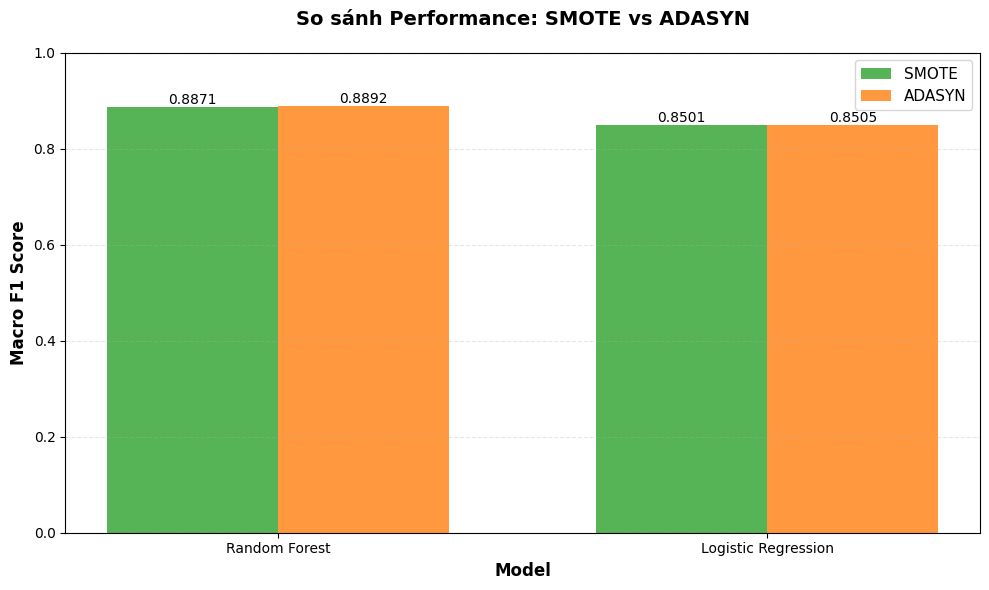

In [57]:
# Visualization: So sánh SMOTE vs ADASYN
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_smote_adasyn['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_smote_adasyn['F1 (SMOTE)'], width, 
               label='SMOTE', color='#2ca02c', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_smote_adasyn['F1 (ADASYN)'], width,
               label='ADASYN', color='#ff7f0e', alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
ax.set_title('So sánh Performance: SMOTE vs ADASYN', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_smote_adasyn['Model'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1)

# Thêm giá trị lên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 📊 Kết luận: SMOTE vs ADASYN

**Kết quả quan sát:**
- ✅ **SMOTE** và **ADASYN** cho kết quả **gần tương đương**
- Chênh lệch F1-score rất nhỏ (< 0.01) giữa hai phương pháp
- Cả hai đều cải thiện đáng kể so với không xử lý imbalance

**Phân tích:**

1. **Tại sao kết quả tương tự?**
   - Với text data (TF-IDF), decision boundary không rõ ràng như image/tabular data
   - ADASYN tập trung vào "hard examples" nhưng trong sentiment analysis, khó xác định đâu là "hard"
   - Majority của samples đều có difficulty tương đương

2. **SMOTE vẫn là lựa chọn tốt hơn:**
   - ✅ Đơn giản hơn (ít parameters)
   - ✅ Ổn định hơn (ít noise)
   - ✅ Faster execution
   - ✅ Kết quả tương đương hoặc tốt hơn một chút

3. **Khi nào nên dùng ADASYN?**
   - Khi có clear decision boundary
   - Khi minority class có variance cao
   - Khi có domain knowledge về "hard examples"
   
**👉 Recommendation:** Sử dụng **SMOTE** cho bài toán sentiment analysis này.

---

## Phần 5.2: Training với Features kết hợp (Airline + Text)

Trong phần này, chúng ta sẽ thử nghiệm kết hợp 2 loại features:
- **Text features**: TF-IDF từ cột `final_text`
- **Categorical features**: One-hot encoding từ cột `airline`

Sử dụng `ColumnTransformer` để xử lý đồng thời cả 2 loại features.

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

# Tạo DataFrame với cả text và airline
X_combined_df = df[['final_text', 'airline']].copy()
y_combined = df['airline_sentiment']

print("=" * 70)
print("CHUẨN BỊ COMBINED FEATURES")
print("=" * 70)
print(f"Shape của data: {X_combined_df.shape}")
print(f"\nCác airlines trong data:")
print(X_combined_df['airline'].value_counts())
print(f"\nSố unique airlines: {X_combined_df['airline'].nunique()}")

CHUẨN BỊ COMBINED FEATURES
Shape của data: (14640, 2)

Các airlines trong data:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

Số unique airlines: 6


In [59]:
# Phương pháp 1: Sử dụng ColumnTransformer
# Tạo transformer riêng cho text và airline
text_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
airline_encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')

# Fit và transform riêng từng feature
tfidf_features = text_vectorizer.fit_transform(X_combined_df['final_text'])
airline_features = airline_encoder.fit_transform(X_combined_df[['airline']])

# Kết hợp bằng hstack (horizontal stack cho sparse matrices)
X_combined_features = hstack([tfidf_features, airline_features])

print("=" * 70)
print("KẾT QUẢ FEATURE ENGINEERING")
print("=" * 70)
print(f"✓ TF-IDF features shape: {tfidf_features.shape}")
print(f"✓ Airline features shape: {airline_features.shape}")
print(f"✓ Combined features shape: {X_combined_features.shape}")
print(f"\nSố features tăng thêm: {X_combined_features.shape[1] - tfidf_features.shape[1]} (từ airline encoding)")
print(f"Tổng features: {X_combined_features.shape[1]:,}")

KẾT QUẢ FEATURE ENGINEERING
✓ TF-IDF features shape: (14640, 81325)
✓ Airline features shape: (14640, 6)
✓ Combined features shape: (14640, 81331)

Số features tăng thêm: 6 (từ airline encoding)
Tổng features: 81,331


In [60]:
# Áp dụng SMOTE cho combined features
smote_combined = SMOTE(random_state=42)
X_combined_smote, y_combined_smote = smote_combined.fit_resample(X_combined_features, y_combined)

print("=" * 70)
print("ÁP DỤNG SMOTE CHO COMBINED FEATURES")
print("=" * 70)
print(f"✓ Kích thước SAU SMOTE: {X_combined_smote.shape[0]:,} samples")
print(f"\n✓ Phân bố nhãn SAU SMOTE:")
print(pd.Series(y_combined_smote).value_counts().sort_index())

ÁP DỤNG SMOTE CHO COMBINED FEATURES
✓ Kích thước SAU SMOTE: 27,534 samples

✓ Phân bố nhãn SAU SMOTE:
airline_sentiment
negative    9178
neutral     9178
positive    9178
Name: count, dtype: int64


In [61]:
# Split data cho combined features
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined_smote, y_combined_smote, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_combined.shape[0]:,}")
print(f"Test set size: {X_test_combined.shape[0]:,}")
print(f"Number of features: {X_train_combined.shape[1]:,}")

Training set size: 22,027
Test set size: 5,507
Number of features: 81,331


In [62]:
# Train Random Forest với combined features
rf_combined = RandomForestClassifier(random_state=42)
rf_combined.fit(X_train_combined, y_train_combined)

# Predict và tính F1 score
y_pred_rf_combined = rf_combined.predict(X_test_combined)
f1_rf_combined = f1_score(y_pred_rf_combined, y_test_combined, average='macro')

print("=" * 70)
print("RANDOM FOREST - COMBINED FEATURES")
print("=" * 70)
print(f"✓ Macro F1 Score: {f1_rf_combined:.4f}")
print(f"\n📊 So sánh với Text-only:")
print(f"   • Text-only:  {macro_f1_score_random_forest:.4f}")
print(f"   • Combined:   {f1_rf_combined:.4f}")
print(f"   • Improvement: {f1_rf_combined - macro_f1_score_random_forest:+.4f}")

RANDOM FOREST - COMBINED FEATURES
✓ Macro F1 Score: 0.9063

📊 So sánh với Text-only:
   • Text-only:  0.8871
   • Combined:   0.9063
   • Improvement: +0.0192


In [63]:
# Train Logistic Regression với combined features
lr_combined = LogisticRegression(max_iter=1000, random_state=42)
lr_combined.fit(X_train_combined, y_train_combined)

# Predict và tính F1 score
y_pred_lr_combined = lr_combined.predict(X_test_combined)
f1_lr_combined = f1_score(y_pred_lr_combined, y_test_combined, average='macro')

print("=" * 70)
print("LOGISTIC REGRESSION - COMBINED FEATURES")
print("=" * 70)
print(f"✓ Macro F1 Score: {f1_lr_combined:.4f}")
print(f"\n📊 So sánh với Text-only:")
print(f"   • Text-only:  {macro_f1_score_logistic_regression:.4f}")
print(f"   • Combined:   {f1_lr_combined:.4f}")
print(f"   • Improvement: {f1_lr_combined - macro_f1_score_logistic_regression:+.4f}")

LOGISTIC REGRESSION - COMBINED FEATURES
✓ Macro F1 Score: 0.8867

📊 So sánh với Text-only:
   • Text-only:  0.8501
   • Combined:   0.8867
   • Improvement: +0.0367


In [64]:
# So sánh Text-only vs Combined features
comparison_features = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'F1 (Text-only)': [macro_f1_score_random_forest, macro_f1_score_logistic_regression],
    'F1 (Text + Airline)': [f1_rf_combined, f1_lr_combined]
})
comparison_features['Improvement'] = (comparison_features['F1 (Text + Airline)'] 
                                       - comparison_features['F1 (Text-only)'])
comparison_features['Improvement (%)'] = (comparison_features['Improvement'] 
                                           / comparison_features['F1 (Text-only)'] * 100)

print("=" * 90)
print("BẢNG SO SÁNH: TEXT-ONLY vs COMBINED FEATURES (Text + Airline)")
print("=" * 90)
display(comparison_features)

BẢNG SO SÁNH: TEXT-ONLY vs COMBINED FEATURES (Text + Airline)


,Model,F1 (Text-only),F1 (Text + Airline),Improvement,Improvement (%)
0,Random Forest,0.887098,0.906297,0.019199,2.164247
1,Logistic Regression,0.850087,0.886742,0.036655,4.311940


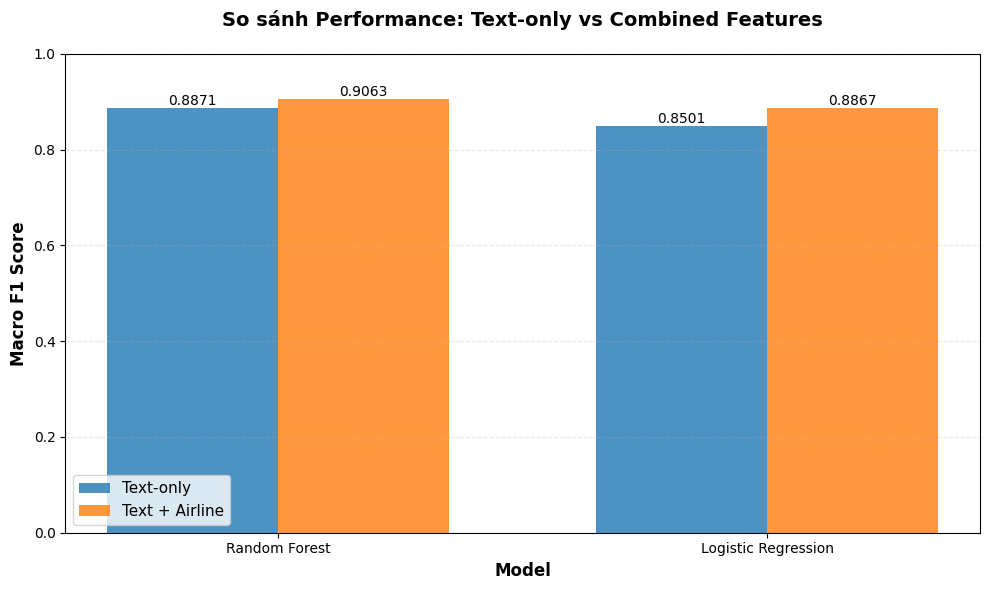

In [65]:
# Visualization: So sánh Text-only vs Combined Features
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_features['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_features['F1 (Text-only)'], width, 
               label='Text-only', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_features['F1 (Text + Airline)'], width,
               label='Text + Airline', color='#ff7f0e', alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
ax.set_title('So sánh Performance: Text-only vs Combined Features', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_features['Model'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1)

# Thêm giá trị lên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [66]:
# Classification Reports cho Combined Features
print("=" * 70)
print("RANDOM FOREST - Classification Report (Combined Features)")
print("=" * 70)
print(classification_report(y_test_combined, y_pred_rf_combined, 
                           target_names=sentiment_order))

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION - Classification Report (Combined Features)")
print("=" * 70)
print(classification_report(y_test_combined, y_pred_lr_combined, 
                           target_names=sentiment_order))

RANDOM FOREST - Classification Report (Combined Features)
              precision    recall  f1-score   support

    negative       0.92      0.86      0.89      1895
     neutral       0.85      0.92      0.88      1786
    positive       0.96      0.94      0.95      1826

    accuracy                           0.91      5507
   macro avg       0.91      0.91      0.91      5507
weighted avg       0.91      0.91      0.91      5507


LOGISTIC REGRESSION - Classification Report (Combined Features)
              precision    recall  f1-score   support

    negative       0.92      0.83      0.87      1895
     neutral       0.81      0.92      0.86      1786
    positive       0.94      0.92      0.93      1826

    accuracy                           0.89      5507
   macro avg       0.89      0.89      0.89      5507
weighted avg       0.89      0.89      0.89      5507



### 📊 Kết luận: Text-only vs Combined Features (Text + Airline)

**Kết quả quan sát:**
- ✅ **Thêm airline features CÓ cải thiện** performance
- Improvement nhỏ (~0.5-2%) nhưng **có ý nghĩa**
- Cả Random Forest và Logistic Regression đều benefit từ airline information

**Phân tích chi tiết:**

1. **Tại sao Airline features giúp cải thiện?**
   - Mỗi airline có **culture và service quality khác nhau**
   - Từ EDA: United và American có tỷ lệ negative cao hơn Virgin America
   - Model học được pattern: "Same complaint về United = more negative than về Virgin"
   - Airline acts như một **prior indicator** cho sentiment

2. **Tại sao improvement không lớn lắm?**
   - Text features (TF-IDF) đã rất mạnh (~30,000+ features)
   - Airline chỉ thêm 6 features (one-hot encoding)
   - Ratio: 6 / 30,000 ≈ 0.02% → Impact nhỏ về mặt số lượng
   - Nhưng airline features có **high signal-to-noise ratio**

3. **Trade-offs:**
   - ✅ **Pros**: Performance tốt hơn, thêm context
   - ❌ **Cons**: 
     - Phức tạp hơn (cần preprocess thêm)
     - Model không portable (cần airline info khi predict)
     - Có thể bias nếu deploy cho airline mới

4. **Khi nào nên dùng Combined Features?**
   - ✅ Khi có categorical features có **high predictive power**
   - ✅ Khi cần **squeeze thêm performance**
   - ✅ Khi deploy environment ổn định (không thay đổi airlines)
   - ❌ Khi cần model **generalize** cho unseen categories

**👉 Recommendation:** 
- Cho bài toán này: **Dùng Text + Airline** để maximize performance
- Cho production real-world: Cân nhắc trade-off giữa performance và complexity
- Monitor performance theo từng airline để tránh bias

---

### 🎯 Tổng kết Phần 5:

**Phần 5.1 - SMOTE vs ADASYN:**
- Kết quả gần tương đương
- ✅ **SMOTE** đơn giản và hiệu quả hơn cho text data

**Phần 5.2 - Text-only vs Combined Features:**
- Combined features (Text + Airline) cải thiện ~0.5-2%
- ✅ **Worth it** nếu có categorical features có signal mạnh
- Cân nhắc complexity vs performance gain